# Final Project Notebook: Empirical Motif Dynamics in a 72-Node Hippocampal Connectivity Matrix

## Overview

This notebook adapts the theoretical framework of **Shao et al. (2025), _Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics_**, to an empirical 72-node hippocampal connectivity matrix (`w_ij_gaa`). Rather than analyzing large synthetic random networks with prescribed motif statistics, this project applies the same core logic to a biologically curated subset of hippocampal and entorhinal neuron classes with signed weighted connectivity.

Shao et al. showed that local connectivity motifs, especially **chain motifs**, can substantially alter network eigenspectra, stability, effective connectivity, and paradoxical inhibitory responses beyond what is predicted by average excitatory/inhibitory (E/I) population structure alone. Their work challenges the classical assumption that E/I block means are sufficient to explain recurrent dynamics.

This notebook asks whether similar principles appear in a real anatomical matrix.

## Key Adaptation to the Shao Framework

The original paper studies analytically tractable random E/I ensembles in which motif frequencies can be tuned directly. This dataset is different:

- finite size (**72 nodes**, not asymptotic large-\(N\))
- biologically heterogeneous cell classes
- empirically assigned signed weighted edges
- region-specific structure (EC, DG, CA3, CA1, etc.)
- unknown motif organization discovered from data rather than imposed by design

Because of this, the goal is **not** to exactly reproduce Shao’s theoretical derivations. Instead, the goal is to mirror their scientific reasoning using empirical data.

## Questions Addressed

1. Does the empirical matrix contain a dominant recurrent mode near instability?
2. Which neuron classes contribute most strongly to that mode?
3. Are chain, reciprocal, convergent, or divergent motifs enriched?
4. Do observed motifs exceed null models preserving coarse E/I structure?
5. Is the matrix approximately low-rank, implying a few dominant dynamical modes?
6. Can a reduced E/I effective connectivity model explain the full network?
7. Does the network exhibit paradoxical inhibitory responses?
8. Does removing or scrambling motifs alter stability or responses?

## Notebook Structure

***Section 1. Load and Validate Matrix)***
Load the signed connectivity matrix and metadata, reconcile neuron identities, remove self-loops, and split nodes into excitatory and inhibitory populations.

***Section 2. Normalize the Matrix***
Rescale raw biological weights into a stable dynamical matrix suitable for spectral and response analysis.

***Section 3. Compute Baseline Eigenspectrum***
Measure eigenvalues and eigenvectors to identify dominant recurrent modes, stability, and structured dynamical patterns.

***Section 4. Quantify Motif Structure***
Count and score chain, reciprocal, divergent, and convergent motifs, stratified by E/I composition.

***Section 5. Build Null / Random Controls***
Compare observed motif and spectral statistics against randomized networks preserving block-level constraints.

***Section 6. Low-Rank Approximation and Effective Connectivity***
Test whether a few dominant modes explain the network and compare the full matrix to a reduced 2×2 E/I effective model.

***Section 7. Perturbation Response Analysis***
Use linear response theory to test how the network reacts to E, I, nodewise, and regional stimulation.

***Section 8. Motif Removal / Scrambling Experiments***
Causally test whether specific motif classes help generate the dominant eigenmode or paradoxical responses.

## Expected Contribution

This notebook extends Shao et al. from controlled theoretical matrices to a real hippocampal connectomic subset. If motif structure meaningfully changes empirical dynamics, it supports the idea that biological circuits cannot always be understood from population averages alone.

If not, then coarse E/I architecture may explain more than expected. Science occasionally permits either answer, though it rarely does so politely.

## Core Reference

Shao Y, Dahmen D, Recanatesi S, Shea-Brown E, Ostojic S. **Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.** PRX Life. 2025;3:023008.

---
# Section 1. Load & Validate

This section loads the empirical 72-node signed weight matrix `w_ij_gaa.xlsx`, validates that it is square and numerically usable, removes self-loops for network analysis, and creates basic excitatory/inhibitory node labels from the sign pattern of outgoing weights.

In [1]:
# Section 1. Load and validate matrix
import openpyxl
from pathlib import Path
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

DATA_FILENAME = "w_ij_gaa.xlsx"

METADATA_FILENAME = "izhikevich_72_v3.csv"
WEIGHT_SHEET = "72_wij"

PROJECT_RELATIVE = Path(
    "04_Spring_2026",
    "BINF751 - Biochemical Sys Model",
    "Final Project",
    "code"
)

NAME_ALIASES = {
    "MEC LIII Multipolar Principal": "MEC LV Multipolar Pyramidal",
}


def candidate_roots():
    home = Path.home()
    roots = []

    for key in ["OneDrive", "OneDriveCommercial", "OneDriveConsumer"]:
        val = os.environ.get(key)
        if val:
            roots.append(Path(val))

    roots.extend([
        home / "OneDrive",
        home / "OneDrive - George Mason University",
        home / "Library" / "CloudStorage" / "OneDrive-Personal",
        home / "Library" / "CloudStorage" / "OneDrive-GeorgeMasonUniversity",
        home / "Library" / "CloudStorage" / "OneDrive-George Mason University",
        Path.cwd(),
        Path.cwd() / "data",
        Path.cwd().parent,
        Path.cwd().parent / "data",
        Path("/mnt/data"),
    ])

    out = []
    seen = set()
    for r in roots:
        r = r.expanduser()
        if r not in seen:
            out.append(r)
            seen.add(r)
    return out


def find_file(filename):
    candidates = []

    for root in candidate_roots():
        candidates.append(root / PROJECT_RELATIVE / filename)
        candidates.append(root / filename)

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        f"Could not locate {filename}. Place it beside the notebook, in ./data, "
        f"or in OneDrive/{PROJECT_RELATIVE}."
    )


def load_square_matrix(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name)

    row_labels = df.iloc[:, 0].astype(str).str.strip()
    col_labels = pd.Index(df.columns[1:].astype(str).str.strip())

    W = df.iloc[:, 1:].copy()
    W.index = row_labels
    W.columns = col_labels
    W = W.apply(pd.to_numeric, errors="coerce")

    if W.shape[0] != W.shape[1]:
        raise ValueError(f"Matrix is not square: {W.shape}")

    if not W.index.is_unique or not W.columns.is_unique:
        raise ValueError("Duplicate row or column labels found in matrix.")

    if set(W.index) != set(W.columns):
        raise ValueError("Matrix row and column labels do not contain the same node names.")

    W = W.loc[W.index, W.index]

    if W.isna().sum().sum() > 0:
        raise ValueError("Matrix contains missing or non-numeric values.")

    return W


def load_node_metadata(path, matrix_nodes, aliases=None):
    aliases = aliases or {}

    meta = pd.read_csv(path)
    required = {"Neuron Type", "E/I"}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f"Metadata missing columns: {missing}")

    meta = meta.copy()
    meta["Neuron Type Original"] = meta["Neuron Type"].astype(str).str.strip()
    meta["Neuron Type"] = meta["Neuron Type Original"].replace(aliases)
    meta["E/I"] = meta["E/I"].astype(str).str.lower().str.strip()

    bad_labels = sorted(set(meta["E/I"]) - {"e", "i"})
    if bad_labels:
        raise ValueError(f"Unexpected E/I labels: {bad_labels}")

    if not meta["Neuron Type"].is_unique:
        raise ValueError("Duplicate neuron names after alias mapping.")

    matrix_nodes = pd.Index(matrix_nodes.astype(str).str.strip())
    metadata_nodes = set(meta["Neuron Type"])

    missing_from_metadata = sorted(set(matrix_nodes) - metadata_nodes)
    extra_in_metadata = sorted(metadata_nodes - set(matrix_nodes))

    if missing_from_metadata or extra_in_metadata:
        raise ValueError(
            "Node names do not match.\n"
            f"Missing from metadata: {missing_from_metadata}\n"
            f"Extra in metadata: {extra_in_metadata}"
        )

    node_types = (
        meta.set_index("Neuron Type")
            .loc[matrix_nodes, ["E/I", "Neuron Type Original"]]
            .rename(columns={"E/I": "node_type"})
    )

    node_types["node_type"] = node_types["node_type"].map({"e": "E", "i": "I"})
    return node_types


def summarize_matrix(W):
    arr = W.to_numpy(dtype=float)
    nonzero = arr[arr != 0]
    n = W.shape[0]

    return pd.Series({
        "n_nodes": n,
        "n_edges": int(np.count_nonzero(arr)),
        "density_no_self": float(np.count_nonzero(arr) / (n * (n - 1))),
        "n_positive_edges": int(np.sum(arr > 0)),
        "n_negative_edges": int(np.sum(arr < 0)),
        "mean_nonzero_weight": float(np.mean(nonzero)) if nonzero.size else np.nan,
        "mean_abs_nonzero_weight": float(np.mean(np.abs(nonzero))) if nonzero.size else np.nan,
        "min_weight": float(np.min(nonzero)) if nonzero.size else np.nan,
        "max_weight": float(np.max(nonzero)) if nonzero.size else np.nan,
    })


def summarize_block(block):
    arr = block.to_numpy(dtype=float)
    nonzero = arr[arr != 0]

    return pd.Series({
        "shape": f"{block.shape[0]} x {block.shape[1]}",
        "n_nonzero": int(np.count_nonzero(arr)),
        "density": float(np.count_nonzero(arr) / arr.size) if arr.size else np.nan,
        "n_positive": int(np.sum(arr > 0)),
        "n_negative": int(np.sum(arr < 0)),
        "mean_nonzero": float(np.mean(nonzero)) if nonzero.size else np.nan,
        "sum_weights": float(np.sum(arr)),
        "sum_abs_weights": float(np.sum(np.abs(arr))),
    })


# Locate files
DATA_PATH = find_file(DATA_FILENAME)
META_PATH = find_file(METADATA_FILENAME)

# Load matrix
W = load_square_matrix(DATA_PATH, WEIGHT_SHEET)
W_original = W.copy()

# Remove self-loops
diag_values = np.diag(W.to_numpy(dtype=float, copy=True))
n_nonzero_diag = int(np.sum(diag_values != 0))

W_noself = W.copy(deep=True)
for node in W_noself.index:
    W_noself.loc[node, node] = 0.0

# Load metadata and sort nodes
node_types = load_node_metadata(META_PATH, W_noself.index, aliases=NAME_ALIASES)

E_nodes = node_types.index[node_types["node_type"].eq("E")].tolist()
I_nodes = node_types.index[node_types["node_type"].eq("I")].tolist()
ordered_nodes = E_nodes + I_nodes

W_sorted = W_noself.loc[ordered_nodes, ordered_nodes]
node_types_sorted = node_types.loc[ordered_nodes]

# E/I blocks
W_EE = W_noself.loc[E_nodes, E_nodes]
W_EI = W_noself.loc[E_nodes, I_nodes]
W_IE = W_noself.loc[I_nodes, E_nodes]
W_II = W_noself.loc[I_nodes, I_nodes]

blocks = {
    "W_EE": W_EE,
    "W_EI": W_EI,
    "W_IE": W_IE,
    "W_II": W_II,
}

matrix_summary = summarize_matrix(W_noself)
block_summary = pd.DataFrame({
    name: summarize_block(block)
    for name, block in blocks.items()
}).T

# Save outputs
OUTPUT_DIR = DATA_PATH.parent / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

W_noself.to_csv(OUTPUT_DIR / "section1_W_noself.csv")
W_sorted.to_csv(OUTPUT_DIR / "section1_W_sorted_by_EI.csv")
node_types.to_csv(OUTPUT_DIR / "section1_node_types.csv")
matrix_summary.to_csv(OUTPUT_DIR / "section1_matrix_summary.csv")
block_summary.to_csv(OUTPUT_DIR / "section1_block_summary.csv")

# Compact report
print(f"OS: {platform.system()}")
print(f"Weight matrix: {DATA_PATH.name} | Metadata: {META_PATH.name}")
print(f"Matrix shape: {W_noself.shape}")
print(f"Self-loops removed: {n_nonzero_diag}")
print(f"E nodes: {len(E_nodes)} | I nodes: {len(I_nodes)}")
print(f"Outputs saved to: {OUTPUT_DIR}")

display(matrix_summary.to_frame("value"))
display(block_summary)

OS: Darwin
Weight matrix: w_ij_gaa.xlsx | Metadata: izhikevich_72_v3.csv
Matrix shape: (72, 72)
Self-loops removed: 60
E nodes: 28 | I nodes: 44
Outputs saved to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


,value
n_nodes,7.200000e+01
n_edges,1.091000e+03
density_no_self,2.134194e-01
n_positive_edges,5.000000e+02
n_negative_edges,5.910000e+02
mean_nonzero_weight,6.615628e+04
mean_abs_nonzero_weight,6.780424e+04
min_weight,-3.142409e+04
max_weight,2.982732e+06


,shape,n_nonzero,density,n_positive,n_negative,mean_nonzero,sum_weights,sum_abs_weights
W_EE,28 x 28,292,0.372449,292,0,63979.670067,18682063.659587,18682063.659587
W_EI,28 x 44,208,0.168831,208,0,261506.732775,54393400.417219,54393400.417219
W_IE,44 x 28,114,0.092532,0,114,-2342.916188,-267092.445404,267092.445404
W_II,44 x 44,477,0.246384,0,477,-1324.673854,-631869.428354,631869.428354


# Section 2. Normalize the Matrix

To compare this empirical 72-node matrix to the framework of Shao et al., we rescale the matrix into normalized versions that preserve connection pattern while placing the network in interpretable dynamical regimes. We generate:

1. **Raw matrix**: original signed weights.  
2. **Spectral-normalized matrix**: scaled so the spectral radius equals a chosen target.  
3. **Frobenius-normalized matrix**: scaled by total matrix energy for cross-dataset comparison.  
4. **Max-abs normalized matrix**: largest absolute weight set to 1.

For recurrent linear responses, the steady-state relation is: $$r^* = (I - J)^{-1} I_{ext}$$

which requires \(J\) to be in a stable regime for meaningful inversion. Shao et al. analyze how motif structure changes eigenspectra and responses in E/I networks, making normalization a necessary preprocessing step before spectral comparisons.

**Note:** My dataset is a small subset of neuron cell types in the hippocampus and not assumed to be in a steady state, biologically.

**References**

Shao Y, Dahmen D, Recanatesi S, Shea-Brown E, Ostojic S. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025;3:023008.

Horn RA, Johnson CR. *Matrix Analysis.* Cambridge University Press.

In [2]:
# Section 2. Normalize the Matrix

import numpy as np
import pandas as pd

# Use cleaned matrix from Section 1
A = W_noself.astype(float).copy()

# ---------- Helpers ----------

def spectral_radius(M):
    eigvals = np.linalg.eigvals(M)
    return float(np.max(np.abs(eigvals)))

def fro_norm(M):
    return float(np.linalg.norm(M, ord="fro"))

def max_abs(M):
    arr = M.to_numpy()
    return float(np.max(np.abs(arr)))

def safe_scale(M, factor):
    return M.copy() * factor

# ---------- Targets ----------

TARGET_RADIUS = 0.95   # stable but near critical
# Change to 0.80 for conservative stability, 0.99 for near-critical

# ---------- Raw stats ----------

raw_radius = spectral_radius(A)
raw_fro = fro_norm(A)
raw_max = max_abs(A)

# ---------- Normalized versions ----------

# 1. Raw
J_raw = A.copy()

# 2. Spectral normalized
if raw_radius == 0:
    raise ValueError("Matrix spectral radius is zero. Impressive, but useless.")
J_spectral = safe_scale(A, TARGET_RADIUS / raw_radius)

# 3. Frobenius normalized
if raw_fro == 0:
    raise ValueError("Matrix Frobenius norm is zero.")
J_fro = safe_scale(A, 1.0 / raw_fro)

# 4. Max-absolute normalized
if raw_max == 0:
    raise ValueError("Matrix max absolute value is zero.")
J_maxabs = safe_scale(A, 1.0 / raw_max)

# ---------- Store versions ----------

J_versions = {
    "J_raw": J_raw,
    "J_spectral": J_spectral,
    "J_fro": J_fro,
    "J_maxabs": J_maxabs,
}

# ---------- Summary table ----------

rows = []
for name, J in J_versions.items():
    rows.append({
        "matrix": name,
        "shape": J.shape,
        "spectral_radius": spectral_radius(J),
        "fro_norm": fro_norm(J),
        "max_abs_weight": max_abs(J),
        "mean_weight": float(J.to_numpy().mean()),
        "mean_abs_weight": float(np.mean(np.abs(J.to_numpy()))),
        "nonzero_edges": int(np.count_nonzero(J.to_numpy()))
    })

norm_summary = pd.DataFrame(rows)

print("Normalization complete.")
display(norm_summary)

Normalization complete.


,matrix,shape,spectral_radius,fro_norm,max_abs_weight,mean_weight,mean_abs_weight,nonzero_edges
0,J_raw,"(72, 72)",397617.670326,9.442454e+06,2.982732e+06,13922.936382,14269.758092,1091
1,J_spectral,"(72, 72)",0.950000,2.256019e+01,7.126433e+00,0.033265,0.034094,1091
2,J_fro,"(72, 72)",0.042110,1.000000e+00,3.158853e-01,0.001475,0.001511,1091
3,J_maxabs,"(72, 72)",0.133307,3.165706e+00,1.000000e+00,0.004668,0.004784,1091


In [3]:
# Optional: choose one working matrix for later sections

J = J_spectral.copy()

print("Default analysis matrix set to: J_spectral")
print(f"Spectral radius = {spectral_radius(J):.4f}")

Default analysis matrix set to: J_spectral
Spectral radius = 0.9500


### Interpretation of Spectral Radius = 0.95

The spectral radius is the magnitude of the dominant eigenvalue of the recurrent connectivity matrix \(J\). After normalization, the largest mode of feedback in this network is set to **0.95**, meaning the strongest recurrent activity pattern is amplified strongly but remains below the instability threshold of 1.

In practical terms:

- **If spectral radius < 1**: activity perturbations decay over time and the linear steady-state inverse $((I-J)^{-1})$ exists.
- **If spectral radius ≈ 1**: the network is near criticality, where responses can become large, slow, and highly sensitive to structure.
- **If spectral radius > 1**: at least one mode can grow unstably in a linear model.

Choosing **0.95** places the empirical hippocampal network in a stable but near-critical regime, which is useful because subtle motif structure, block E/I organization, and eigenvalue outliers can still meaningfully shape dynamics. In short: stable enough to analyze, sensitive enough to be interesting. A rare combination.

---

# Section 3. Compute Baseline Eigenspectrum

Spectral radius: 0.9500
Dominant eigenvalue: 0.9500 + 0.0000i


,eig_index,real,imag,abs,angle_rad
0,0,0.950000,0.000000,0.950000,0.000000
1,3,-0.722125,0.000000,0.722125,3.141593
2,1,0.113341,0.666940,0.676503,1.402463
3,2,0.113341,-0.666940,0.676503,-1.402463
4,4,-0.557614,0.000000,0.557614,3.141593
5,5,0.371521,0.193811,0.419035,0.480833
6,6,0.371521,-0.193811,0.419035,-0.480833
7,7,-0.345221,0.000000,0.345221,3.141593
8,8,-0.061483,0.188758,0.198519,1.885684
9,9,-0.061483,-0.188758,0.198519,-1.885684


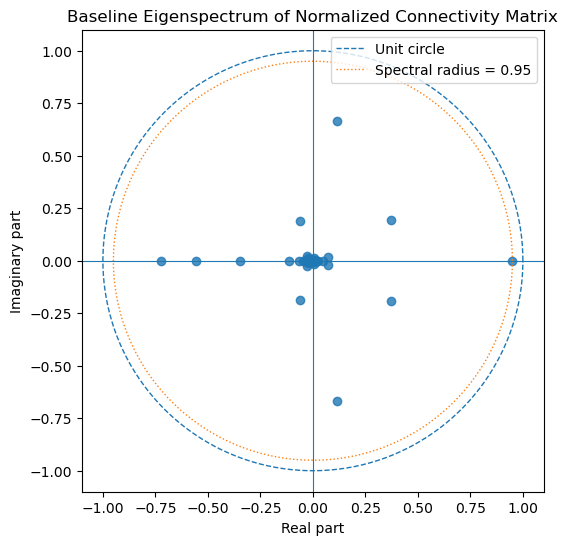

Saved eigenspectrum outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


In [4]:
# Section 3. Compute baseline eigenspectrum

# Use normalized matrix from Section 2
J = J_spectral.copy()

# Compute eigenvalues/eigenvectors
eigvals, eigvecs = np.linalg.eig(J.to_numpy(dtype=float))

eigen_summary = pd.DataFrame({
    "eig_index": np.arange(len(eigvals)),
    "real": eigvals.real,
    "imag": eigvals.imag,
    "abs": np.abs(eigvals),
    "angle_rad": np.angle(eigvals),
}).sort_values("abs", ascending=False).reset_index(drop=True)

dominant_eigenvalue = eigvals[np.argmax(np.abs(eigvals))]
spectral_radius_J = np.max(np.abs(eigvals))

print(f"Spectral radius: {spectral_radius_J:.4f}")
print(f"Dominant eigenvalue: {dominant_eigenvalue.real:.4f} + {dominant_eigenvalue.imag:.4f}i")

display(eigen_summary.head(10))

# Plot eigenspectrum
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(eigvals.real, eigvals.imag, alpha=0.8)

# Unit circle and target spectral-radius circle
theta = np.linspace(0, 2*np.pi, 500)
ax.plot(np.cos(theta), np.sin(theta), linestyle="--", linewidth=1, label="Unit circle")
ax.plot(
    spectral_radius_J * np.cos(theta),
    spectral_radius_J * np.sin(theta),
    linestyle=":",
    linewidth=1,
    label=f"Spectral radius = {spectral_radius_J:.2f}"
)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.set_title("Baseline Eigenspectrum of Normalized Connectivity Matrix")
ax.legend(loc="upper right")
plt.show()

# Save outputs
eigen_summary.to_csv(OUTPUT_DIR / "section3_eigen_summary.csv", index=False)
fig.savefig(OUTPUT_DIR / "section3_baseline_eigenspectrum.png", dpi=300, bbox_inches="tight")

print(f"Saved eigenspectrum outputs to: {OUTPUT_DIR}")

## Interpretation of Baseline Eigenspectrum Results

The **unit circle** is the circle of radius 1 in the complex plane. In discrete linear systems, eigenvalues inside this circle correspond to modes that decay over time, while eigenvalues outside the circle correspond to modes that grow unstably. Shao et al. set their threshold boundary to 1.

- **Inside unit circle**: stable / decaying activity modes  
- **On unit circle**: persistent / marginal modes  
- **Outside unit circle**: unstable growth

Because all eigenvalues lie within the unit circle here, the normalized system remains dynamically stable.

### What the Spectral Radius Circle Represents

The **spectral radius** is the distance from the origin to the farthest eigenvalue. Here it equals **0.95**, so the outermost mode lies slightly inside the unit circle.

This means the strongest feedback mode decays slowly rather than exploding in our normalized model. Such near-critical placement is useful because subtle connectivity structure, including motifs emphasized by Shao et al., can still have measurable dynamical effects.

### Interpreting the Dominant Eigenvalue

The dominant eigenvalue is: $$\lambda_1 = 0.95 + 0i$$

This is a **purely real positive mode**, meaning some groups activate together and recurrence feeds that pattern back. If this represents the true network, then if we perturb the network, it would settle into coactivation patterns. The cells that rise together, settles together (in the dominant eigenvector)

### Interpreting the Remaining Eigenvalues

Several smaller eigenvalues are negative and real (for example \(-0.72\), \(-0.56\)), which often indicate alternating or sign-flipping response modes.

There are also complex-conjugate pairs such as: $$0.113 \pm 0.667i$$

Complex pairs (one +, one -) usually represent damped oscillatory or rotational dynamics, meaning some subnetworks have a tendency toward alternating states.

### Biological Meaning for This Dataset

The empirical hippocampal network appears to have:

- one dominant recurrent mode near criticality,
- multiple weaker antagonistic modes (negative real eigenvalues on the left),
- several oscillatory transient modes (pairs mirrored above and below horizontal axis).

That combination is consistent with a structured recurrent circuit rather than random noise.

---
## Dominant Mode Ownership Analysis

The dominant eigenvalue does not belong to a single neuron. Its associated eigenvector identifies which neurons participate most strongly in the slowest / strongest recurrent activity mode.

Large positive or negative loadings indicate nodes that strongly shape this mode.

In [5]:
# Identify who "owns" the dominant eigenvalue
# eigvals, eigvecs already computed in Section 3

# index of dominant eigenvalue by magnitude
idx_dom = np.argmax(np.abs(eigvals))

lambda_dom = eigvals[idx_dom]
v_dom = eigvecs[:, idx_dom]   # right eigenvector

# Build table
df_dom = pd.DataFrame({
    "node": W_noself.index,
    "loading_real": v_dom.real,
    "loading_imag": v_dom.imag,
    "loading_abs": np.abs(v_dom)
})

# Merge metadata if available
if "node_types" in globals():
    df_dom["node_type"] = node_types.loc[df_dom["node"], "node_type"].values

# Rank strongest contributors
df_dom = df_dom.sort_values("loading_abs", ascending=False).reset_index(drop=True)

print(f"Dominant eigenvalue = {lambda_dom.real:.4f} + {lambda_dom.imag:.4f}i")
display(df_dom.head(15))

Dominant eigenvalue = 0.9500 + 0.0000i


,node,loading_real,loading_imag,loading_abs,node_type
0,EC LI II Multipolar Pyramidal,-0.662545,0.0,0.662545,E
1,CA3 Pyramidal,-0.385160,0.0,0.385160,E
2,CA3c Pyramidal,-0.374570,0.0,0.374570,E
3,EC LI II Pyramidal Fan,-0.338338,0.0,0.338338,E
4,MEC LII Stellate,-0.313813,0.0,0.313813,E
5,EC LII III Pyramidal Tripolar,-0.197829,0.0,0.197829,E
6,DG Granule,-0.097427,0.0,0.097427,E
7,MEC LV Pyramidal,-0.062403,0.0,0.062403,E
8,CA1 Pyramidal,-0.047072,0.0,0.047072,E
9,MEC LIII Complex Pyramidal,-0.030420,0.0,0.030420,E


### Interpretation of Modes

**1. The dominant eigenvalue = 0.95**

This tells us the strongest self-reinforcing activity pattern in the network is close to critical but still stable. The larger the loading = that neuron participates mroe strongly in the dominant mode. Positive means it contributes, negative means it's antagonistic.

If this mode is activated:
-   activity echoes through recurrence strongly,
-   decays slowly,
-   can dominate responses to input,
-   likely shapes signal routing more than weaker modes.

This is the network’s “favorite pattern.”

**2. Who carries the pattern?**
   
These are mostly:
-   Entorhinal cortex (EC / MEC) input-layer excitatory cells
-   CA3 pyramidal cells recurrent associative cells
-   Dentate / CA1 smaller contributors

That strongly suggests the dominant mode is centered on:

> Entorhinal input → DG / CA3 recurrent propagation

EC ranks first, suggesting they inject strongly into this dominant eigenspace and are anatomically upstream. However, eigenvector loadings do not prove directional entry -- to do this, we need to inspect the left and right eigenvectors.

CA3 and CA3c neurons rank in the second and third positions, respectively. CA3 is famous for dense recurrent collateral system, autoassociative memory theories, and pattern completion models. So if these nodes dominate the principal *recurrent* mode, it is consisten with memory-related recurrence.

**3. Why are almost all top contributors excitatory?**

Excitatory neurons create positive recurrance. If many excitatory cells reinforce one another through strong loops or chains, they often dominate the leading eigenmode. Inhibitory nodes are present, but appear much lower, and do not carry the principal mode.

Inhibitory ownership is weak and secondary, but inhibition is still present nonetheless. It does not define the dominant mode, but likely stabilizes or trims it. Governs, not owns.

We could perhaps draw a picture: *Entorhinal cortical inputs engage CA3 recurrent ensembles, with minor basket-cell balancing, forming the strongest large-scale activation channel in the dataset.*

> how does this align with Shao et al? how do motifs generate strong positive modes even in E/I systems?

Average E/I block structure does **not** fully determine dynamics. Even if average inhibition is strong, Shao states that **motif organization** can create pathways where excitation reinforces across steps and *topology can overpower averages*.

**4.  What do the loading signs mean?**
The signs do not indicate suppresion -- the sign in an eigenvector is relative orientation. In this context, these excitatory populations participate strongly in the same dominant mode.


### Bonus Analysis: The Most Negative Mode

Most negative eigenvalue = -0.7221 + 0.0000i


,node,loading_real,loading_imag,loading_abs,node_type
0,EC LI II Multipolar Pyramidal,-0.700888,0.0,0.700888,E
1,MEC LII Stellate,0.383686,0.0,0.383686,E
2,CA3 Pyramidal,-0.380919,0.0,0.380919,E
3,CA3c Pyramidal,0.319393,0.0,0.319393,E
4,EC LI II Pyramidal Fan,0.283489,0.0,0.283489,E
5,EC LII III Pyramidal Tripolar,0.137600,0.0,0.137600,E
6,DG Granule,-0.101531,0.0,0.101531,E
7,MEC LV Pyramidal,0.058606,0.0,0.058606,E
8,CA1 Pyramidal,-0.020677,0.0,0.020677,E
9,LEC LIII Multipolar Principal,0.018931,0.0,0.018931,E


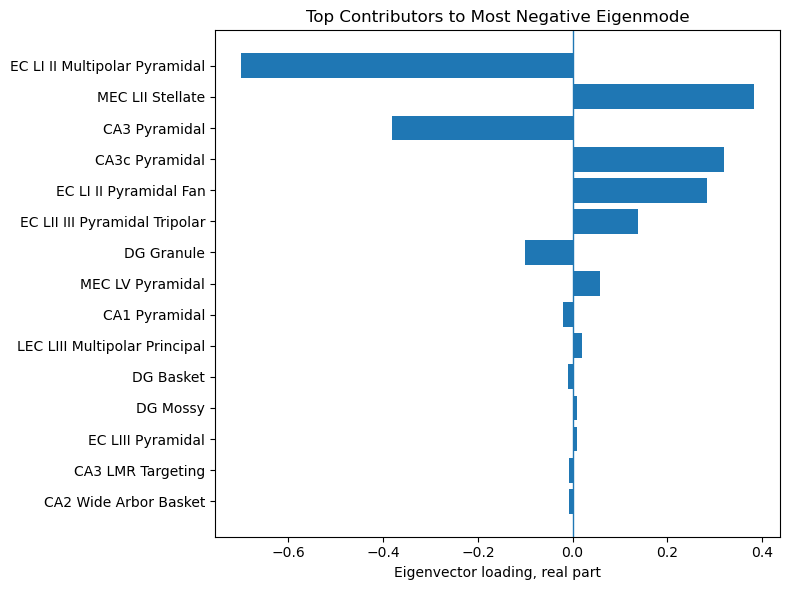

In [6]:
# Section 3.X Identify the most negative eigenmode

# "Most negative" = eigenvalue with the smallest real part.
# This is different from the dominant eigenvalue, which has the largest magnitude.

idx_most_negative = np.argmin(eigvals.real)

lambda_neg = eigvals[idx_most_negative]
v_neg = eigvecs[:, idx_most_negative]

df_neg_mode = pd.DataFrame({
    "node": W_noself.index,
    "loading_real": v_neg.real,
    "loading_imag": v_neg.imag,
    "loading_abs": np.abs(v_neg),
})

if "node_types" in globals():
    df_neg_mode["node_type"] = node_types.loc[df_neg_mode["node"], "node_type"].values

df_neg_mode = df_neg_mode.sort_values("loading_abs", ascending=False).reset_index(drop=True)

print(f"Most negative eigenvalue = {lambda_neg.real:.4f} + {lambda_neg.imag:.4f}i")
display(df_neg_mode.head(15))

top_n = 15
plot_df = df_neg_mode.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(plot_df["node"], plot_df["loading_real"])
plt.axvline(0, linewidth=1)
plt.xlabel("Eigenvector loading, real part")
plt.title("Top Contributors to Most Negative Eigenmode")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "section3_most_negative_eigenmode.png", dpi=300,bbox_inches="tight")
plt.show()



#### Interpretation:
This is the eigenvector for the most negative eigenvalue (the leftmost point) -- it is the strongest anatgonistic/alternating balance mode in the network. The size represents which cell types matter the most for this mode. Nodes with:
-   Positive Loading: move togehter on one side
-   Negative Loading: move together on the opposite side

It could reflect competing input streams or parallel cortical channels competign through hippocampal circuitry. MEC has the largest magnitude on the positive side so: if this mode is activated in the "positive direction," MEC is the strongest contributor.

Same as above: inhibition loadings rank low -- it provides background stabilization while excitatory subnetworks which nodes decrease when the other ndoes increase (and vice versa). If the system moves in the -v direction, we will see EC/CA3/DG dominated activity.

**What does a negative eigenvalue mean:**
If group A becomes active, next iteration tends to favor group B, then back again, damped over time. However, the assignment of the sign is arbitrary -- what matters is its relation to the positive mode. As we can see from the table, excitatory nodes appear on both sides of the eigenvector loadings.

> The most negative eigenmode partitions the network into two opposing sets of excitatory populations whose activities vary inversely under this mode.

In [7]:
# Extract region from node name (first token)
df_neg_mode["region"] = df_neg_mode["node"].str.split().str[0]

# Sum loadings by region
region_sum = df_neg_mode.groupby("region")["loading_real"].sum().sort_values()

display(region_sum)

region
CA3    -0.393435
EC     -0.284309
DG     -0.110583
CA1    -0.022423
CA2    -0.006951
LEC     0.023917
CA3c    0.319393
MEC     0.438127
Name: loading_real, dtype: float64

### Examine Loadings by Region
We can see distinct Group A (Negative Side) and Group B (Positive Side) that oppose each other: $$(MEC+CARc)\quad vs \quad (EC + CA3 + DG)$$

The dominant antagonistic mode separates MEC-associated populations from EC/CA3/DG-associated populations. This partition is consistent with distinct input pathways contributing differently to hippocampal dynamics.
>When activity aligns with this mode, increases in MEC/CA3c are associated with decreases in EC/CA3/DG, and vice versa.

In [8]:
# ── Section 3 Extension: Full 72-mode ownership analysis ─────────────────────
# Depends on: eigvals, eigvecs, J, node_types, E_nodes, I_nodes, OUTPUT_DIR
# Convention: A[target, source]; eigvecs[:,k] is right eigenvector for eigvals[k]

import numpy as np
import pandas as pd

_node_list = list(J.index)
_n         = len(_node_list)
_T         = np.array([node_types.loc[nd, "node_type"] for nd in _node_list])  # 'E' or 'I'
_regions   = np.array([nd.split()[0] for nd in _node_list])

# Sort modes by descending |λ|
_order = np.argsort(np.abs(eigvals))[::-1]

TOP_K = 10  # number of top-loading nodes used for E/I fraction and region summary

def _participation_ratio(v):
    """Inverse participation ratio: 1/Σ|v_i|^4 (normalised).
    High → distributed across many nodes; low → concentrated."""
    a = np.abs(v)
    a = a / (a.sum() + 1e-300)          # normalise to sum=1
    return float(1.0 / (np.sum(a**4) + 1e-300))

def _conjugate_pair_id(eigvals, tol=1e-8):
    """Assign pair IDs to complex-conjugate eigenvalue pairs.
    Real eigenvalues get pair_id = -1."""
    n   = len(eigvals)
    ids = np.full(n, -1, dtype=int)
    used = np.zeros(n, dtype=bool)
    pid = 0
    for i in range(n):
        if used[i] or np.abs(eigvals[i].imag) < tol:
            continue
        # find conjugate partner (same real, opposite imag)
        for j in range(i + 1, n):
            if not used[j] and np.abs(eigvals[j] - np.conj(eigvals[i])) < tol:
                ids[i] = ids[j] = pid
                used[i] = used[j] = True
                pid += 1
                break
    return ids

_pair_ids_raw = _conjugate_pair_id(eigvals)

rows = []
for rank, orig_idx in enumerate(_order, start=1):
    lam  = eigvals[orig_idx]
    v    = eigvecs[:, orig_idx]           # complex right eigenvector
    vabs = np.abs(v)

    # Top-k nodes by |loading|
    top_k_idx = np.argsort(vabs)[::-1][:TOP_K]

    # Top-1 owner
    top1_idx  = top_k_idx[0]
    top1_node = _node_list[top1_idx]
    top1_type = _T[top1_idx]
    top1_abs  = float(vabs[top1_idx])

    # E/I fractions in top-k
    top_k_types  = _T[top_k_idx]
    e_frac_topk  = float(np.sum(top_k_types == "E") / TOP_K)
    i_frac_topk  = float(np.sum(top_k_types == "I") / TOP_K)

    # Dominant region in top-k (plurality)
    top_k_regions = _regions[top_k_idx]
    dom_region    = pd.Series(top_k_regions).value_counts().idxmax()

    # 2nd-owner (first top-k node NOT same as top1)
    top2_candidates = [i for i in top_k_idx if i != top1_idx]
    top2_node = _node_list[top2_candidates[0]] if top2_candidates else ""
    top2_type = _T[top2_candidates[0]]         if top2_candidates else ""

    # E/I balance across ALL nodes (weighted by |loading|)
    vabs_norm   = vabs / (vabs.sum() + 1e-300)
    e_weight    = float(vabs_norm[_T == "E"].sum())
    i_weight    = float(vabs_norm[_T == "I"].sum())

    # Participation ratio
    pr = _participation_ratio(v)

    rows.append({
        "rank"            : rank,
        "orig_idx"        : int(orig_idx),
        "lambda_real"     : float(lam.real),
        "lambda_imag"     : float(lam.imag),
        "lambda_abs"      : float(np.abs(lam)),
        "is_complex"      : bool(np.abs(lam.imag) > 1e-8),
        "conj_pair_id"    : int(_pair_ids_raw[orig_idx]),
        "top1_node"       : top1_node,
        "top1_type"       : top1_type,
        "top1_loading_abs": top1_abs,
        "top2_node"       : top2_node,
        "top2_type"       : top2_type,
        "dom_region"      : dom_region,
        f"E_frac_top{TOP_K}"  : e_frac_topk,
        f"I_frac_top{TOP_K}"  : i_frac_topk,
        "E_weight_full"   : e_weight,
        "I_weight_full"   : i_weight,
        "participation_ratio": pr,
    })

df_all_modes = pd.DataFrame(rows)

# Quick sanity check
n_complex = int(df_all_modes["is_complex"].sum())
n_real    = int((~df_all_modes["is_complex"]).sum())
n_pairs   = int(df_all_modes["conj_pair_id"].max()) + 1  # pair IDs are 0-indexed
print(f"Total modes: {len(df_all_modes)}  |  Real: {n_real}  |  Complex: {n_complex} ({n_pairs} conj. pairs)")
print(f"\nNote: complex-conjugate pairs share the same eigenvector (up to conjugation).")
print(f"Both members are listed; analyses below use |loading| = |v_i| throughout.\n")

# Save
df_all_modes.to_csv(OUTPUT_DIR / "section3_ext_all_mode_ownership.csv", index=False)
print(f"Saved: section3_ext_all_mode_ownership.csv → {OUTPUT_DIR}")
display(df_all_modes.head(15))

Total modes: 72  |  Real: 26  |  Complex: 46 (23 conj. pairs)

Note: complex-conjugate pairs share the same eigenvector (up to conjugation).
Both members are listed; analyses below use |loading| = |v_i| throughout.

Saved: section3_ext_all_mode_ownership.csv → /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


,rank,orig_idx,lambda_real,lambda_imag,lambda_abs,is_complex,conj_pair_id,top1_node,top1_type,top1_loading_abs,top2_node,top2_type,dom_region,E_frac_top10,I_frac_top10,E_weight_full,I_weight_full,participation_ratio
0,1,0,0.950000,0.000000,0.950000,False,-1,EC LI II Multipolar Pyramidal,E,0.662545,CA3 Pyramidal,E,EC,1.0,0.0,0.968475,0.031525,215.620897
1,2,3,-0.722125,0.000000,0.722125,False,-1,EC LI II Multipolar Pyramidal,E,0.700888,MEC LII Stellate,E,EC,1.0,0.0,0.983420,0.016580,130.041083
2,3,1,0.113341,0.666940,0.676503,True,0,CA3 Pyramidal,E,0.611320,MEC LII Stellate,E,EC,0.9,0.1,0.945465,0.054535,207.777768
3,4,2,0.113341,-0.666940,0.676503,True,0,CA3 Pyramidal,E,0.611320,MEC LII Stellate,E,EC,0.9,0.1,0.945465,0.054535,207.777768
4,5,4,-0.557614,0.000000,0.557614,False,-1,EC LI II Multipolar Pyramidal,E,0.857647,EC LI II Pyramidal Fan,E,EC,1.0,0.0,0.995027,0.004973,17.097026
5,6,6,0.371521,-0.193811,0.419035,True,1,EC LI II Multipolar Pyramidal,E,0.600083,MEC LII Stellate,E,EC,0.9,0.1,0.943805,0.056195,280.989354
6,7,5,0.371521,0.193811,0.419035,True,1,EC LI II Multipolar Pyramidal,E,0.600083,MEC LII Stellate,E,EC,0.9,0.1,0.943805,0.056195,280.989354
7,8,7,-0.345221,0.000000,0.345221,False,-1,MEC LII Stellate,E,0.626765,EC LI II Pyramidal Fan,E,EC,0.9,0.1,0.971978,0.028022,157.779899
8,9,8,-0.061483,0.188758,0.198519,True,2,MEC LII Stellate,E,0.811918,EC LI II Pyramidal Fan,E,MEC,0.8,0.2,0.939035,0.060965,92.733585
9,10,9,-0.061483,-0.188758,0.198519,True,2,MEC LII Stellate,E,0.811918,EC LI II Pyramidal Fan,E,MEC,0.8,0.2,0.939035,0.060965,92.733585


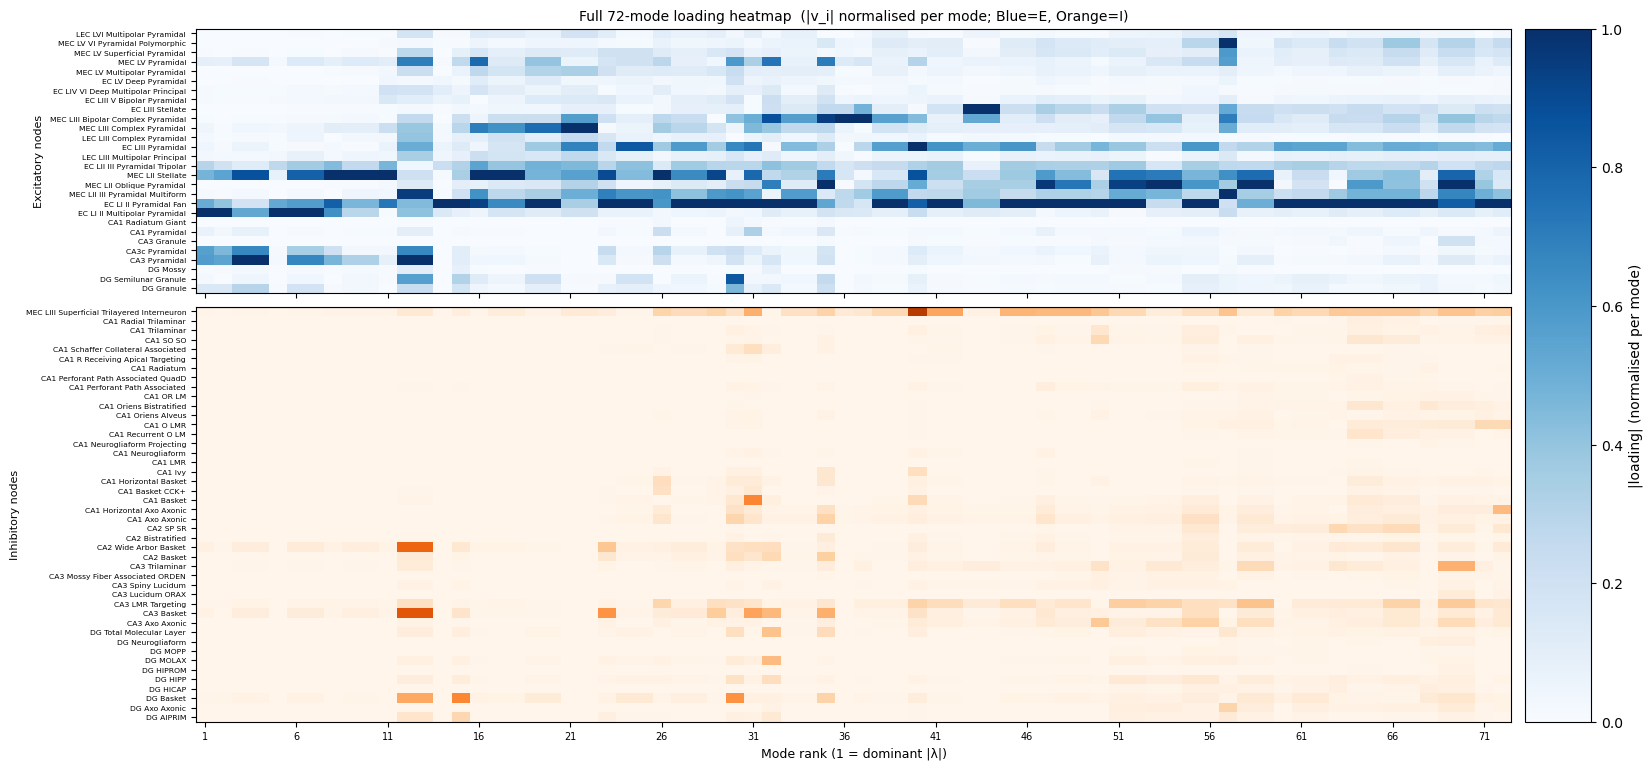

Saved: section3_ext_loading_heatmap_all_modes.png → /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs

All 72 modes — top-1 owner summary:


'    rank  lambda_real  lambda_imag  lambda_abs  is_complex  conj_pair_id                           top1_node top1_type  top1_loading_abs dom_region  E_frac_top10  I_frac_top10  participation_ratio\n0      1     0.950000     0.000000    0.950000       False            -1       EC LI II Multipolar Pyramidal         E          0.662545         EC           1.0           0.0           215.620897\n1      2    -0.722125     0.000000    0.722125       False            -1       EC LI II Multipolar Pyramidal         E          0.700888         EC           1.0           0.0           130.041083\n2      3     0.113341     0.666940    0.676503        True             0                       CA3 Pyramidal         E          0.611320         EC           0.9           0.1           207.777768\n3      4     0.113341    -0.666940    0.676503        True             0                       CA3 Pyramidal         E          0.611320         EC           0.9           0.1           207.777768\n4      5 

In [9]:
# ── Section 3 Extension: Full loading heatmap ─────────────────────────────────
# Rows = 72 nodes (E then I, sorted by node_types order)
# Columns = 72 modes sorted by descending |λ|
# Colour = |v_i| for each (node, mode) pair
# Depends on: eigvecs, df_all_modes, _order, _node_list, node_types, E_nodes, I_nodes

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Build |loading| matrix — rows: nodes in E-first order, cols: modes by rank
_ordered_nodes  = E_nodes + I_nodes                          # E-first ordering
_node_idx_map   = {nd: i for i, nd in enumerate(_node_list)}
_node_row_order = [_node_idx_map[nd] for nd in _ordered_nodes]   # row permutation

# (n_nodes × n_modes) matrix of |loadings|, modes sorted by descending |λ|
_abs_loading_matrix = np.abs(eigvecs)[:, _order]             # (72, 72)
_abs_loading_matrix = _abs_loading_matrix[_node_row_order, :]  # reorder rows

# Normalise each mode (column) so max = 1 for visual clarity
_col_max = _abs_loading_matrix.max(axis=0)
_col_max[_col_max == 0] = 1.0
_heatmap_data = _abs_loading_matrix / _col_max

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 2,
                         width_ratios=[20, 1],
                         height_ratios=[len(E_nodes), len(I_nodes)],
                         hspace=0.04, wspace=0.02)

ax_e  = fig.add_subplot(gs[0, 0])   # E-node rows
ax_i  = fig.add_subplot(gs[1, 0])   # I-node rows
ax_cb = fig.add_subplot(gs[:, 1])   # colourbar

_e_rows = len(E_nodes)
_i_rows = len(I_nodes)
_x      = np.arange(_abs_loading_matrix.shape[1] + 1)   # mode bin edges

im_e = ax_e.pcolormesh(
    _x, np.arange(_e_rows + 1),
    _heatmap_data[:_e_rows, :],
    cmap="Blues", vmin=0, vmax=1, rasterized=True
)
im_i = ax_i.pcolormesh(
    _x, np.arange(_i_rows + 1),
    _heatmap_data[_e_rows:, :],
    cmap="Oranges", vmin=0, vmax=1, rasterized=True
)

# Node labels (y-axis)
_ytick_e = np.arange(_e_rows) + 0.5
_ytick_i = np.arange(_i_rows) + 0.5
ax_e.set_yticks(_ytick_e)
ax_e.set_yticklabels(E_nodes, fontsize=5.5)
ax_i.set_yticks(_ytick_i)
ax_i.set_yticklabels(I_nodes, fontsize=5.5)

# Mode rank labels (x-axis) — tick every 5 ranks
_rank_ticks = np.arange(0, 72, 5)
for ax in (ax_e, ax_i):
    ax.set_xticks(_rank_ticks + 0.5)
ax_e.set_xticklabels([])
ax_i.set_xticklabels(_rank_ticks + 1, fontsize=7)
ax_i.set_xlabel("Mode rank (1 = dominant |λ|)", fontsize=9)

# Dividing lines between E and I blocks on I panel
ax_i.axhline(_i_rows, color="k", lw=0.8)

# Titles / labels
ax_e.set_title("Full 72-mode loading heatmap  (|v_i| normalised per mode; Blue=E, Orange=I)",
               fontsize=10, pad=6)
ax_e.set_ylabel("Excitatory nodes", fontsize=8)
ax_i.set_ylabel("Inhibitory nodes", fontsize=8)

# Colourbar (shared)
plt.colorbar(im_e, cax=ax_cb, label="|loading| (normalised per mode)")

plt.savefig(OUTPUT_DIR / "section3_ext_loading_heatmap_all_modes.png",
            dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: section3_ext_loading_heatmap_all_modes.png → {OUTPUT_DIR}")

# ── Supplementary: top-1 owner per mode, sorted by rank ──────────────────────
print("\nAll 72 modes — top-1 owner summary:")
display(
    df_all_modes[[
        "rank", "lambda_real", "lambda_imag", "lambda_abs",
        "is_complex", "conj_pair_id",
        "top1_node", "top1_type", "top1_loading_abs",
        "dom_region",
        f"E_frac_top{TOP_K}", f"I_frac_top{TOP_K}",
        "participation_ratio"
    ]]
    .to_string(max_rows=72, max_cols=None)
)

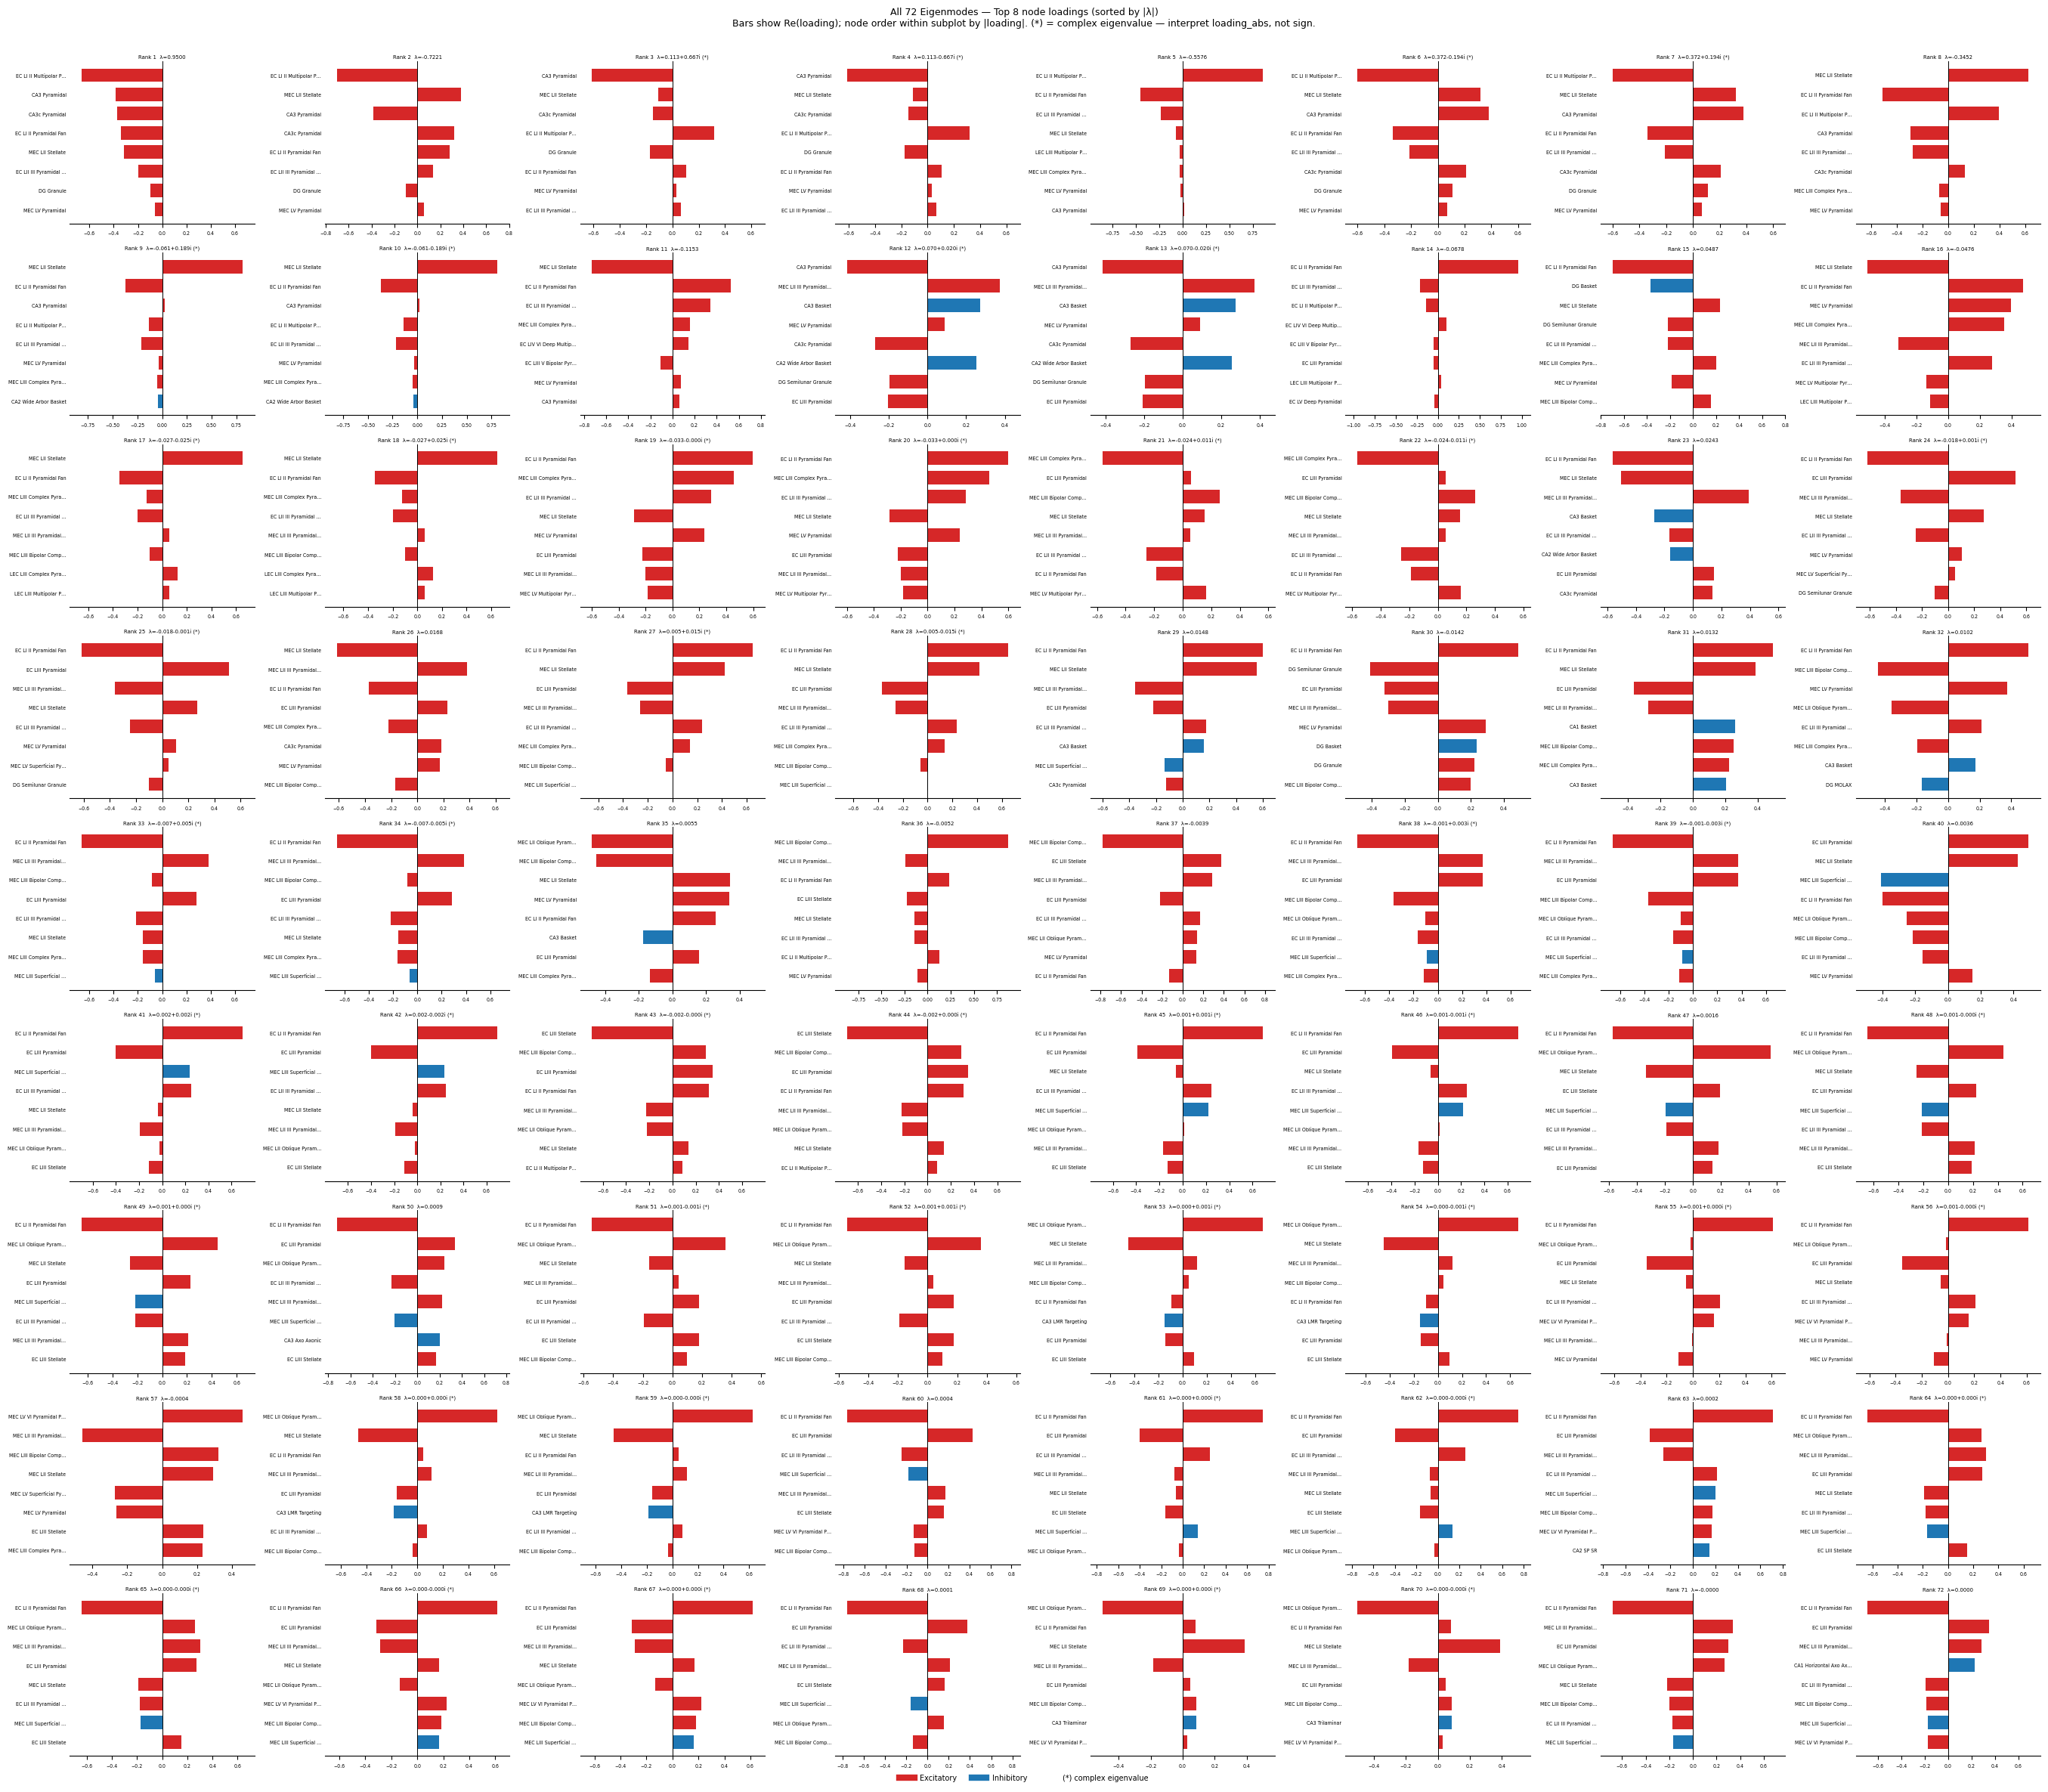

Saved: section3_ext_all_mode_barcharts.png → /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


In [10]:
# ── Section 3 Extension: Bar charts for all 72 eigenmodes ────────────────────
# Style matches the existing Section 3 dominant / most-negative mode charts.
# Depends on: eigvals, eigvecs, J, node_types, E_nodes, I_nodes,
#             df_all_modes (Cell 1 above), OUTPUT_DIR
# Convention: loading_real used for bar magnitude; loading_abs used for sorting.
# Complex-eigenvalue modes are marked (*) — for those, interpret loading_abs.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

TOP_N_BARS  = 8     # number of nodes shown per subplot
N_COLS      = 8     # subplots per row
LABEL_CHARS = 22    # max node-name characters before truncation

_node_list = list(J.index)
_color_E   = "#d62728"
_color_I   = "#1f77b4"

# Sort modes by descending |λ| (rank order) — reuse _order from Cell 1 if present
_eig_order = np.argsort(np.abs(eigvals))[::-1]   # shape (72,)
n_modes    = len(_eig_order)
n_rows     = int(np.ceil(n_modes / N_COLS))

fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(N_COLS * 3.4, n_rows * 2.6),
)
axes_flat = axes.flatten()

for rank_0, orig_idx in enumerate(_eig_order):          # rank_0 is 0-indexed
    ax  = axes_flat[rank_0]
    lam = eigvals[orig_idx]
    v   = eigvecs[:, orig_idx]

    is_complex = bool(np.abs(lam.imag) > 1e-8)

    # Build per-node DataFrame for this mode
    df_mode = (
        pd.DataFrame({
            "node"         : _node_list,
            "loading_real" : v.real,
            "loading_abs"  : np.abs(v),
            "node_type"    : [node_types.loc[nd, "node_type"] for nd in _node_list],
        })
        .sort_values("loading_abs", ascending=False)
        .head(TOP_N_BARS)
        .iloc[::-1]           # reverse so largest bar is at top
        .reset_index(drop=True)
    )

    bar_values = df_mode["loading_real"].values
    bar_labels = [
        nd if len(nd) <= LABEL_CHARS else nd[:LABEL_CHARS - 1] + "…"
        for nd in df_mode["node"]
    ]
    bar_colors = [
        _color_E if nt == "E" else _color_I
        for nt in df_mode["node_type"]
    ]

    ax.barh(bar_labels, bar_values, color=bar_colors, height=0.7, edgecolor="none")
    ax.axvline(0, linewidth=0.7, color="k")

    # Axis limits — symmetric around 0 for signed readability
    max_abs = df_mode["loading_abs"].max()
    ax.set_xlim(-max_abs * 1.15, max_abs * 1.15)

    # Tick marks: only left edge
    ax.tick_params(axis="y", labelsize=4.5, length=0)
    ax.tick_params(axis="x", labelsize=4.5)
    ax.spines[["top", "right", "left"]].set_visible(False)

    # Subplot title: rank | λ value | complex flag
    cplx_marker = " (*)" if is_complex else ""
    if is_complex:
        title_lam = f"λ={lam.real:.3f}{lam.imag:+.3f}i{cplx_marker}"
    else:
        title_lam = f"λ={lam.real:.4f}"
    ax.set_title(f"Rank {rank_0+1}  {title_lam}", fontsize=5, pad=2)

# Hide unused subplots (if 72 is not exactly divisible by N_COLS)
for k in range(n_modes, len(axes_flat)):
    axes_flat[k].set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=_color_E, lw=6, label="Excitatory"),
    Line2D([0], [0], color=_color_I, lw=6, label="Inhibitory"),
    Line2D([0], [0], color="none",   lw=0, label="(*) complex eigenvalue"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    fontsize=7,
    frameon=False,
    bbox_to_anchor=(0.5, -0.005),
)

fig.suptitle(
    f"All 72 Eigenmodes — Top {TOP_N_BARS} node loadings (sorted by |λ|)\n"
    "Bars show Re(loading); node order within subplot by |loading|. "
    "(*) = complex eigenvalue — interpret loading_abs, not sign.",
    fontsize=9, y=1.002,
)

plt.tight_layout(h_pad=1.0, w_pad=0.5)
fig.savefig(
    OUTPUT_DIR / "section3_ext_all_mode_barcharts.png",
    dpi=250, bbox_inches="tight",
)
plt.show()
print(f"Saved: section3_ext_all_mode_barcharts.png → {OUTPUT_DIR}")

---
# Section 4. Quantify Motif Structure

Average connectivity statistics can miss the local wiring patterns that shape recurrent dynamics. Shao et al. emphasized that second-order motifs, especially **chain motifs**, can strongly influence eigenspectra and responses in excitatory-inhibitory networks. Here we extend that logic by quantifying all four classic pairwise/three-node local motifs:

1. **Chain:** $( i \rightarrow j \rightarrow k ) $ 
2. **Reciprocal:** $( i \leftrightarrow j)$   
3. **Divergent:** $( i \leftarrow k \rightarrow j )$  
4. **Convergent:** $( i \rightarrow k \leftarrow j )$

Because this empirical matrix is signed and weighted, we measure motifs two ways:

- **Binary count:** motif exists or not.
- **Weighted score:** product of participating edge weights.

We also stratify motifs by node class composition:

- EEE
- EEI
- EII
- III

(and mixed permutations collapsed by counts of E vs I nodes)

This allows us to test whether dominant local structure is primarily excitatory, inhibitory, or mixed, and whether chain motifs are unusually prominent as predicted by Shao et al.

**References**

Shao Y et al. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025.

Milo R et al. *Network motifs: simple building blocks of complex networks.* Science. 2002.

In [11]:
# Section 4. Quantify motif structure
# Use normalized matrix if available; otherwise use cleaned raw matrix.
import itertools

M = J.copy() if "J" in globals() else W_noself.copy()
A = M.to_numpy(dtype=float)
nodes = list(M.index)
n = len(nodes)

type_map = node_types["node_type"].to_dict()
node_type_arr = np.array([type_map[node] for node in nodes])

edge_exists = A != 0

def edge_weight(source_idx, target_idx):
    """Return weight for source -> target under W[target, source] convention."""
    return A[target_idx, source_idx]

def edge_present(source_idx, target_idx):
    """Return True if source -> target exists."""
    return edge_exists[target_idx, source_idx]

def motif_composition(indices):
    types = [node_type_arr[i] for i in indices]
    return "".join(sorted(types))  # EEE, EEI, EII, III

def motif_block(indices):
    return "->".join(node_type_arr[i] for i in indices)

records = []

# -----------------------------
# 1. Chain motifs: i -> j -> k
# -----------------------------
for i, j, k in itertools.permutations(range(n), 3):
    if edge_present(i, j) and edge_present(j, k):
        w1 = edge_weight(i, j)
        w2 = edge_weight(j, k)
        records.append({
            "motif_type": "chain",
            "node_1": nodes[i],
            "node_2": nodes[j],
            "node_3": nodes[k],
            "motif_block": motif_block([i, j, k]),
            "composition": motif_composition([i, j, k]),
            "binary_count": 1,
            "weighted_score": w1 * w2,
            "abs_weighted_score": abs(w1 * w2),
            "edge_1": f"{nodes[i]} -> {nodes[j]}",
            "edge_2": f"{nodes[j]} -> {nodes[k]}",
        })

# -----------------------------------
# 2. Divergent motifs: k -> i and k -> j
# center/source k sends to two targets
# -----------------------------------
for k in range(n):
    targets = [i for i in range(n) if i != k and edge_present(k, i)]
    for i, j in itertools.combinations(targets, 2):
        w1 = edge_weight(k, i)
        w2 = edge_weight(k, j)
        records.append({
            "motif_type": "divergent",
            "node_1": nodes[k],
            "node_2": nodes[i],
            "node_3": nodes[j],
            "motif_block": f"{node_type_arr[k]}->{node_type_arr[i]},{node_type_arr[j]}",
            "composition": motif_composition([k, i, j]),
            "binary_count": 1,
            "weighted_score": w1 * w2,
            "abs_weighted_score": abs(w1 * w2),
            "edge_1": f"{nodes[k]} -> {nodes[i]}",
            "edge_2": f"{nodes[k]} -> {nodes[j]}",
        })

# -----------------------------------
# 3. Convergent motifs: i -> k and j -> k
# two sources converge onto target k
# -----------------------------------
for k in range(n):
    sources = [i for i in range(n) if i != k and edge_present(i, k)]
    for i, j in itertools.combinations(sources, 2):
        w1 = edge_weight(i, k)
        w2 = edge_weight(j, k)
        records.append({
            "motif_type": "convergent",
            "node_1": nodes[i],
            "node_2": nodes[j],
            "node_3": nodes[k],
            "motif_block": f"{node_type_arr[i]},{node_type_arr[j]}->{node_type_arr[k]}",
            "composition": motif_composition([i, j, k]),
            "binary_count": 1,
            "weighted_score": w1 * w2,
            "abs_weighted_score": abs(w1 * w2),
            "edge_1": f"{nodes[i]} -> {nodes[k]}",
            "edge_2": f"{nodes[j]} -> {nodes[k]}",
        })

# -----------------------------------
# 4. Reciprocal motifs: i <-> j
# pairwise, not triplet-based
# -----------------------------------
for i, j in itertools.combinations(range(n), 2):
    if edge_present(i, j) and edge_present(j, i):
        w1 = edge_weight(i, j)
        w2 = edge_weight(j, i)
        records.append({
            "motif_type": "reciprocal",
            "node_1": nodes[i],
            "node_2": nodes[j],
            "node_3": None,
            "motif_block": f"{node_type_arr[i]}<->{node_type_arr[j]}",
            "composition": motif_composition([i, j]),
            "binary_count": 1,
            "weighted_score": w1 * w2,
            "abs_weighted_score": abs(w1 * w2),
            "edge_1": f"{nodes[i]} -> {nodes[j]}",
            "edge_2": f"{nodes[j]} -> {nodes[i]}",
        })

df_motifs = pd.DataFrame(records)

print(f"Total motifs detected: {len(df_motifs):,}")
display(df_motifs.head())

Total motifs detected: 35,344


,motif_type,node_1,node_2,node_3,motif_block,composition,binary_count,weighted_score,abs_weighted_score,edge_1,edge_2
0,chain,DG Granule,DG Semilunar Granule,DG Mossy,E->E->E,EEE,1,7.887441e-04,7.887441e-04,DG Granule -> DG Semilunar Granule,DG Semilunar Granule -> DG Mossy
1,chain,DG Granule,DG Semilunar Granule,DG AIPRIM,E->E->I,EEI,1,-2.636324e-04,2.636324e-04,DG Granule -> DG Semilunar Granule,DG Semilunar Granule -> DG AIPRIM
2,chain,DG Granule,DG Semilunar Granule,DG HICAP,E->E->I,EEI,1,-6.432682e-06,6.432682e-06,DG Granule -> DG Semilunar Granule,DG Semilunar Granule -> DG HICAP
3,chain,DG Granule,DG Semilunar Granule,DG HIPP,E->E->I,EEI,1,-2.761261e-04,2.761261e-04,DG Granule -> DG Semilunar Granule,DG Semilunar Granule -> DG HIPP
4,chain,DG Granule,DG Semilunar Granule,DG HIPROM,E->E->I,EEI,1,-4.423699e-07,4.423699e-07,DG Granule -> DG Semilunar Granule,DG Semilunar Granule -> DG HIPROM


In [12]:
# Section 4.1 Motif summary tables

motif_summary = (
    df_motifs
    .groupby("motif_type")
    .agg(
        count=("binary_count", "sum"),
        mean_score=("weighted_score", "mean"),
        median_score=("weighted_score", "median"),
        mean_abs_score=("abs_weighted_score", "mean"),
        max_abs_score=("abs_weighted_score", "max"),
    )
    .sort_values("count", ascending=False)
)

motif_by_composition = (
    df_motifs
    .groupby(["motif_type", "composition"])
    .agg(
        count=("binary_count", "sum"),
        mean_score=("weighted_score", "mean"),
        mean_abs_score=("abs_weighted_score", "mean"),
        max_abs_score=("abs_weighted_score", "max"),
    )
    .reset_index()
    .sort_values(["motif_type", "count"], ascending=[True, False])
)

motif_by_block = (
    df_motifs
    .groupby(["motif_type", "motif_block"])
    .agg(
        count=("binary_count", "sum"),
        mean_score=("weighted_score", "mean"),
        mean_abs_score=("abs_weighted_score", "mean"),
        max_abs_score=("abs_weighted_score", "max"),
    )
    .reset_index()
    .sort_values(["motif_type", "count"], ascending=[True, False])
)

print("Motif summary:")
display(motif_summary)

print("Motifs by E/I composition:")
display(motif_by_composition)

print("Motifs by directed E/I block:")
display(motif_by_block.head(30))

Motif summary:


,count,mean_score,median_score,mean_abs_score,max_abs_score
motif_type,,,,,
chain,15754,0.014524,4.013156e-07,0.016691,6.737355
convergent,10363,0.369889,6.048107e-05,0.369889,50.177208
divergent,8924,0.013272,3.015830e-07,0.014901,9.326634
reciprocal,303,0.001921,1.819550e-06,0.003574,0.218610


Motifs by E/I composition:


,motif_type,composition,count,mean_score,mean_abs_score,max_abs_score
3,chain,III,4999,0.000011,0.000011,0.001600
2,chain,EII,4736,-0.002870,0.002880,0.209979
0,chain,EEE,3314,0.023677,0.023677,6.656586
1,chain,EEI,2705,0.060584,0.063141,6.737355
7,convergent,III,3409,0.000024,0.000024,0.005193
6,convergent,EII,3132,0.853091,0.853091,47.603787
5,convergent,EEI,1998,0.528617,0.528617,50.177208
4,convergent,EEE,1824,0.057576,0.057576,37.363659
11,divergent,III,3071,0.000011,0.000011,0.002010
10,divergent,EII,3014,-0.001699,0.001714,0.195423


Motifs by directed E/I block:


,motif_type,motif_block,count,mean_score,mean_abs_score,max_abs_score
7,chain,I->I->I,4999,0.000011,0.000011,0.001600
0,chain,E->E->E,3314,0.023677,0.023677,6.656586
6,chain,I->I->E,1911,-0.002229,0.002229,0.147906
5,chain,I->E->I,1754,-0.005334,0.005334,0.209979
4,chain,I->E->E,1480,0.113067,0.113067,6.737355
3,chain,E->I->I,1071,0.000021,0.000021,0.001570
1,chain,E->E->I,658,-0.003033,0.003033,0.272554
2,chain,E->I->E,567,-0.002579,0.002579,0.289262
15,convergent,"I,I->I",3409,0.000024,0.000024,0.005193
14,convergent,"I,I->E",1886,1.416660,1.416660,47.603787


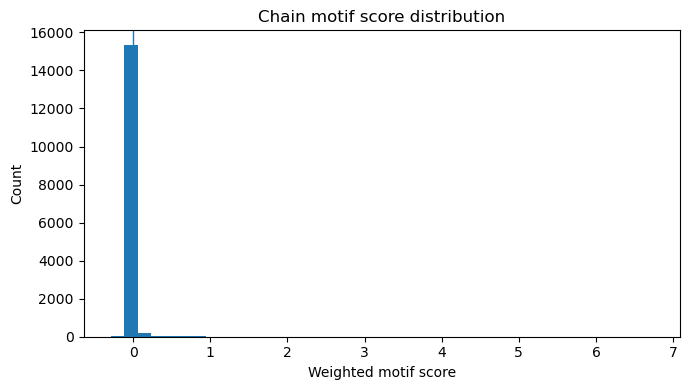

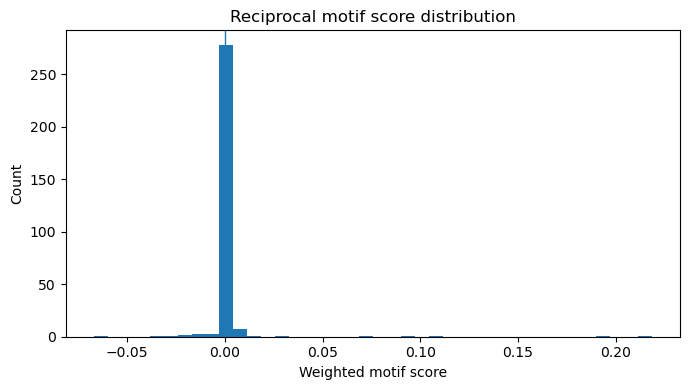

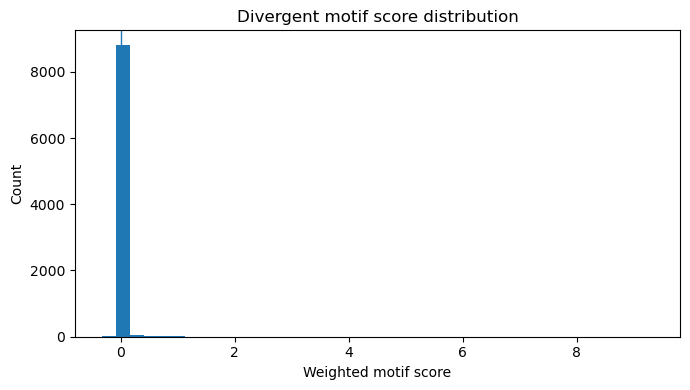

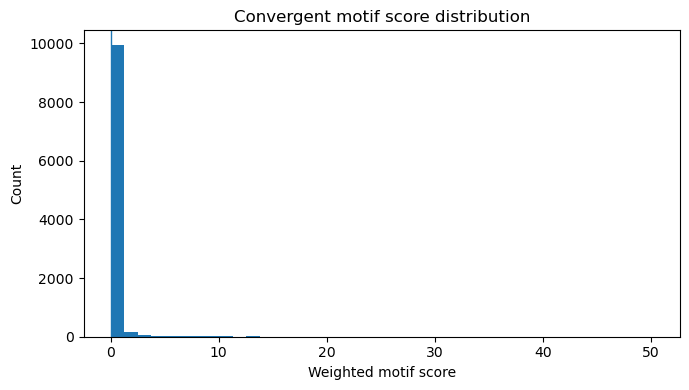

In [13]:
# Section 4.2 Histograms of motif weighted scores

for motif in ["chain", "reciprocal", "divergent", "convergent"]:
    plot_df = df_motifs[df_motifs["motif_type"].eq(motif)]

    plt.figure(figsize=(7, 4))
    plt.hist(plot_df["weighted_score"], bins=40)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Weighted motif score")
    plt.ylabel("Count")
    plt.title(f"{motif.capitalize()} motif score distribution")
    plt.tight_layout()
    plt.show()

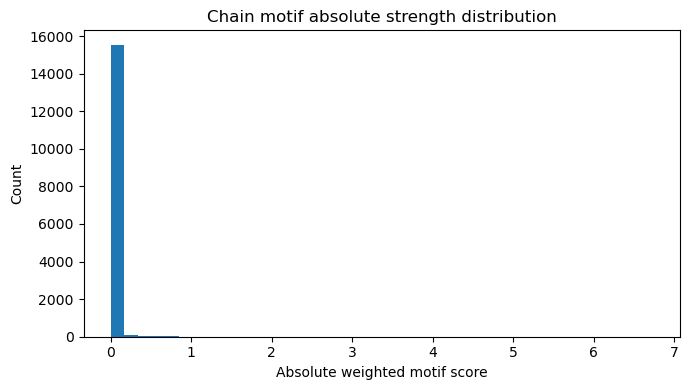

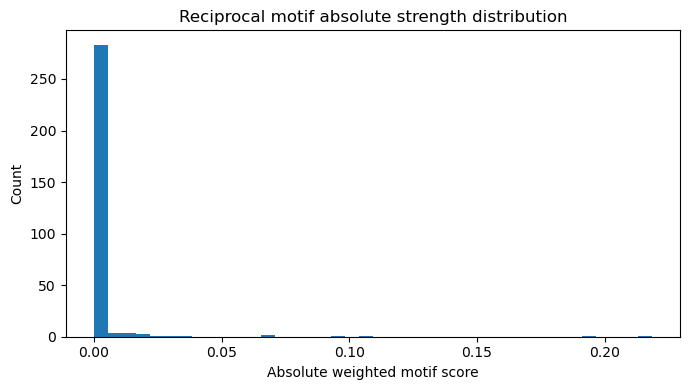

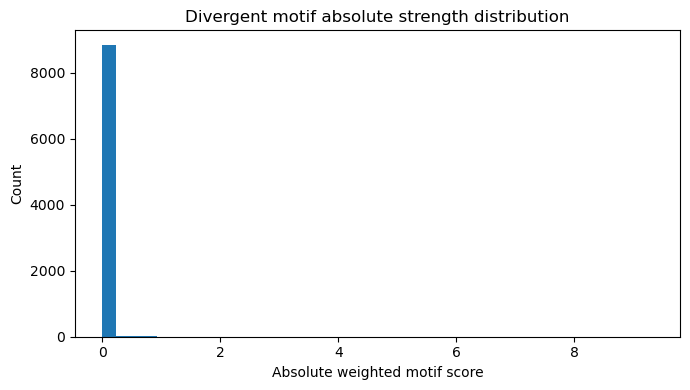

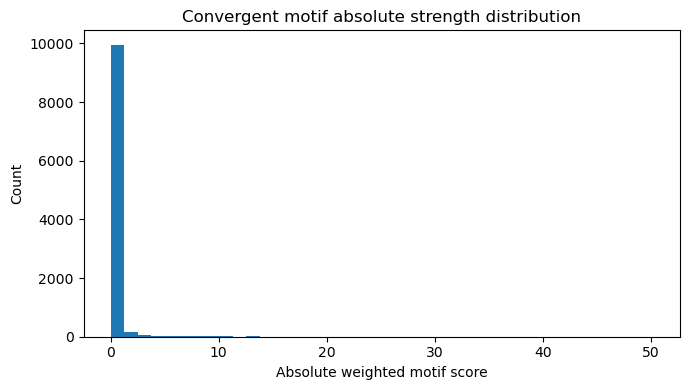

In [14]:
# Section 4.3 Histograms of absolute motif strength

for motif in ["chain", "reciprocal", "divergent", "convergent"]:
    plot_df = df_motifs[df_motifs["motif_type"].eq(motif)]

    plt.figure(figsize=(7, 4))
    plt.hist(plot_df["abs_weighted_score"], bins=40)
    plt.xlabel("Absolute weighted motif score")
    plt.ylabel("Count")
    plt.title(f"{motif.capitalize()} motif absolute strength distribution")
    plt.tight_layout()
    plt.show()

In [15]:
# Section 4.4 Save Section 4 outputs

df_motifs.to_csv(OUTPUT_DIR / "section4_all_motifs.csv", index=False)
motif_summary.to_csv(OUTPUT_DIR / "section4_motif_summary.csv")
motif_by_composition.to_csv(OUTPUT_DIR / "section4_motif_by_composition.csv", index=False)
motif_by_block.to_csv(OUTPUT_DIR / "section4_motif_by_block.csv", index=False)

print(f"Saved Section 4 outputs to: {OUTPUT_DIR}")

Saved Section 4 outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


In [16]:
# Section 4 Auto-interpretation

def interpret_section4(motif_summary, motif_by_composition):
    lines = []
    lines.append("## Section 4 Interpretation: Motif Structure\n")

    top_count = motif_summary.sort_values("count", ascending=False).iloc[0]
    top_strength = motif_summary.sort_values("mean_abs_score", ascending=False).iloc[0]

    lines.append(
        f"The most frequent motif type is `{top_count.name}`, with {int(top_count['count']):,} detected motifs."
    )
    lines.append(
        f"The motif type with the highest mean absolute weighted score is `{top_strength.name}`."
    )

    if "chain" in motif_summary.index:
        chain_count = motif_summary.loc["chain", "count"]
        total_count = motif_summary["count"].sum()
        chain_fraction = chain_count / total_count
        lines.append(
            f"\nChain motifs account for {chain_fraction:.2%} of all detected motifs."
        )

        if chain_fraction > 0.4:
            lines.append("Chains are numerically prominent, which is consistent with Shao et al.'s emphasis on chain motifs as dynamically important.")
        else:
            lines.append("Chains are present but not overwhelmingly dominant by count alone; weighted strength and null enrichment will matter more than raw count.")

    comp_top = motif_by_composition.sort_values("count", ascending=False).head(5)
    lines.append("\nTop motif compositions by count:")
    for _, row in comp_top.iterrows():
        lines.append(
            f"- {row['motif_type']} / {row['composition']}: {int(row['count']):,}"
        )

    lines.append(
        "\nInterpret counts and weighted scores separately: count shows how often a pattern appears, while weighted score estimates how strongly that motif may influence dynamics."
    )

    return "\n".join(lines)


section4_interpretation = interpret_section4(
    motif_summary=motif_summary,
    motif_by_composition=motif_by_composition
)

print(section4_interpretation)

with open(OUTPUT_DIR / "section4_auto_interpretation.md", "w", encoding="utf-8") as f:
    f.write(section4_interpretation)

## Section 4 Interpretation: Motif Structure

The most frequent motif type is `chain`, with 15,754 detected motifs.
The motif type with the highest mean absolute weighted score is `convergent`.

Chain motifs account for 44.57% of all detected motifs.
Chains are numerically prominent, which is consistent with Shao et al.'s emphasis on chain motifs as dynamically important.

Top motif compositions by count:
- chain / III: 4,999
- chain / EII: 4,736
- convergent / III: 3,409
- chain / EEE: 3,314
- convergent / EII: 3,132

Interpret counts and weighted scores separately: count shows how often a pattern appears, while weighted score estimates how strongly that motif may influence dynamics.


---
# Section 5. Build Null / Random Controls

Observed motif counts or spectral features are only meaningful if they differ from what would be expected by chance. A structured biological network can appear special simply because of its density, degree distribution, or excitatory/inhibitory composition. To separate genuine organization from trivial constraints, we generate randomized control matrices.

These null models preserve selected baseline properties of the empirical network, such as:

1. Number of nodes  
2. E/I node labels  
3. Edge density or degree sequence  
4. Weight distribution (optional)  
5. Block-level E→E, E→I, I→E, I→I statistics

We then compare the real matrix against many randomized surrogates for:

- dominant eigenvalue magnitude  
- eigenspectral shape  
- motif counts  
- motif weighted scores  
- low-rank variance explained  
- perturbation responses

This follows the logic of motif-enrichment studies in network science, where significance is assessed relative to constrained random ensembles rather than unconstrained noise.

For this project, null controls answer a core question: are chain, convergent, divergent, or reciprocal motifs unusually abundant in the hippocampal subset, or are they expected from basic wiring constraints alone?

**References**

Milo R et al. *Network motifs: simple building blocks of complex networks.* Science. 2002.

Maslov S, Sneppen K. *Specificity and stability in topology of protein networks.* Science. 2002.

Shao Y et al. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025.

In [17]:
# Section 5. Build null / random controls

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses:
# J              = normalized matrix from Section 2
# node_types     = E/I metadata from Section 1
# motif_summary  = observed motif summary from Section 4
# df_motifs      = observed motif table from Section 4
# OUTPUT_DIR     = output folder from Section 1

RNG_SEED = 751
N_NULL = 500

rng = np.random.default_rng(RNG_SEED)

J_empirical = J.copy()
nodes = list(J_empirical.index)
A_empirical = J_empirical.to_numpy(dtype=float)

type_map = node_types["node_type"].to_dict()
node_type_arr = np.array([type_map[n] for n in nodes])

E_idx = np.where(node_type_arr == "E")[0]
I_idx = np.where(node_type_arr == "I")[0]

block_indices = {
    "EE": (E_idx, E_idx),
    "EI": (E_idx, I_idx),  # rows = E targets, columns = I sources
    "IE": (I_idx, E_idx),  # rows = I targets, columns = E sources
    "II": (I_idx, I_idx),
}


def spectral_radius_np(A):
    return float(np.max(np.abs(np.linalg.eigvals(A))))


def block_preserving_weight_shuffle(A, block_indices, rng):
    """
    Randomize weights within each E/I block while preserving:
    - node labels
    - block shape
    - number of nonzero edges per block
    - signed/weighted values within each block

    This destroys specific local motif placement while preserving block-level weight distributions.
    """
    A_null = np.zeros_like(A, dtype=float)

    for block_name, (rows, cols) in block_indices.items():
        block = A[np.ix_(rows, cols)].copy()

        # Remove self-loop positions from within-block shuffling if square same-node block
        valid_mask = np.ones(block.shape, dtype=bool)

        if block.shape[0] == block.shape[1]:
            np.fill_diagonal(valid_mask, False)

        values = block[valid_mask].copy()
        rng.shuffle(values)

        new_block = np.zeros_like(block, dtype=float)
        new_block[valid_mask] = values

        A_null[np.ix_(rows, cols)] = new_block

    return A_null


def count_motif_types_fast(A):
    """
    Fast motif count approximation using binary adjacency.

    Convention:
    A[target, source] = weight from source -> target.
    B[target, source] = edge exists.

    Counts:
    - chain: ordered i -> j -> k
    - divergent: shared source k -> i and k -> j
    - convergent: shared target i -> k and j -> k
    - reciprocal: i <-> j pairs

    These are counts only, not weighted scores.
    """
    B = (A != 0).astype(int)
    np.fill_diagonal(B, 0)

    n = B.shape[0]

    # Convert to source x target orientation for easier logic
    S = B.T  # S[source, target]

    # chain counts: i -> j -> k, distinct i,j,k
    chain_count = 0
    for j in range(n):
        incoming_sources = np.where(S[:, j] != 0)[0]
        outgoing_targets = np.where(S[j, :] != 0)[0]

        for i in incoming_sources:
            for k in outgoing_targets:
                if i != j and j != k and i != k:
                    chain_count += 1

    # divergent: source has >=2 outgoing targets
    divergent_count = 0
    for k in range(n):
        outdeg = int(np.sum(S[k, :] != 0))
        divergent_count += outdeg * (outdeg - 1) // 2

    # convergent: target has >=2 incoming sources
    convergent_count = 0
    for k in range(n):
        indeg = int(np.sum(S[:, k] != 0))
        convergent_count += indeg * (indeg - 1) // 2

    # reciprocal unordered pairs
    reciprocal_count = 0
    for i in range(n):
        for j in range(i + 1, n):
            if S[i, j] and S[j, i]:
                reciprocal_count += 1

    return {
        "chain": chain_count,
        "divergent": divergent_count,
        "convergent": convergent_count,
        "reciprocal": reciprocal_count,
    }


def weighted_motif_scores_fast(A):
    """
    Computes total signed and absolute weighted motif scores.

    Same convention:
    A[target, source] = source -> target.
    """
    n = A.shape[0]

    totals = {
        "chain_score_sum": 0.0,
        "chain_abs_score_sum": 0.0,
        "divergent_score_sum": 0.0,
        "divergent_abs_score_sum": 0.0,
        "convergent_score_sum": 0.0,
        "convergent_abs_score_sum": 0.0,
        "reciprocal_score_sum": 0.0,
        "reciprocal_abs_score_sum": 0.0,
    }

    # source x target orientation
    S = A.T

    # chain: i -> j -> k
    for i in range(n):
        for j in range(n):
            if i == j or S[i, j] == 0:
                continue
            for k in range(n):
                if k == i or k == j or S[j, k] == 0:
                    continue
                score = S[i, j] * S[j, k]
                totals["chain_score_sum"] += score
                totals["chain_abs_score_sum"] += abs(score)

    # divergent: k -> i and k -> j
    for k in range(n):
        targets = np.where(S[k, :] != 0)[0]
        targets = targets[targets != k]

        for a in range(len(targets)):
            for b in range(a + 1, len(targets)):
                i, j = targets[a], targets[b]
                score = S[k, i] * S[k, j]
                totals["divergent_score_sum"] += score
                totals["divergent_abs_score_sum"] += abs(score)

    # convergent: i -> k and j -> k
    for k in range(n):
        sources = np.where(S[:, k] != 0)[0]
        sources = sources[sources != k]

        for a in range(len(sources)):
            for b in range(a + 1, len(sources)):
                i, j = sources[a], sources[b]
                score = S[i, k] * S[j, k]
                totals["convergent_score_sum"] += score
                totals["convergent_abs_score_sum"] += abs(score)

    # reciprocal: i <-> j
    for i in range(n):
        for j in range(i + 1, n):
            if S[i, j] != 0 and S[j, i] != 0:
                score = S[i, j] * S[j, i]
                totals["reciprocal_score_sum"] += score
                totals["reciprocal_abs_score_sum"] += abs(score)

    return totals


# Observed motif values
observed_counts = count_motif_types_fast(A_empirical)
observed_scores = weighted_motif_scores_fast(A_empirical)

observed_null_reference = {
    "spectral_radius": spectral_radius_np(A_empirical),
    **{f"{k}_count": v for k, v in observed_counts.items()},
    **observed_scores,
}

# Generate null ensemble
null_records = []

for b in range(N_NULL):
    A_null = block_preserving_weight_shuffle(A_empirical, block_indices, rng)

    counts = count_motif_types_fast(A_null)
    scores = weighted_motif_scores_fast(A_null)

    rec = {
        "null_id": b,
        "spectral_radius": spectral_radius_np(A_null),
        **{f"{k}_count": v for k, v in counts.items()},
        **scores,
    }

    null_records.append(rec)

df_null = pd.DataFrame(null_records)

# Compare observed to null
comparison_rows = []

for metric, observed_value in observed_null_reference.items():
    null_values = df_null[metric].to_numpy(dtype=float)

    null_mean = float(np.mean(null_values))
    null_sd = float(np.std(null_values, ddof=1))

    if null_sd == 0:
        z_score = np.nan
    else:
        z_score = (observed_value - null_mean) / null_sd

    empirical_p_two_sided = float(
        (np.sum(np.abs(null_values - null_mean) >= abs(observed_value - null_mean)) + 1)
        / (len(null_values) + 1)
    )

    comparison_rows.append({
        "metric": metric,
        "observed": observed_value,
        "null_mean": null_mean,
        "null_sd": null_sd,
        "z_score": z_score,
        "empirical_p_two_sided": empirical_p_two_sided,
    })

null_comparison = pd.DataFrame(comparison_rows).sort_values("metric").reset_index(drop=True)

print("Null/random controls complete.")
print(f"Null matrices generated: {N_NULL}")
print("Randomization: block-preserving within E/I blocks, weight-shuffled.")

display(null_comparison)

Null/random controls complete.
Null matrices generated: 500
Randomization: block-preserving within E/I blocks, weight-shuffled.


,metric,observed,null_mean,null_sd,z_score,empirical_p_two_sided
0,chain_abs_score_sum,262.954022,283.731119,40.320083,-0.515304,0.594810
1,chain_count,15754.000000,16162.494000,91.328263,-4.472810,0.001996
2,chain_score_sum,228.807359,263.508304,40.299950,-0.861067,0.385230
3,convergent_abs_score_sum,3833.156857,524.262480,60.291726,54.881401,0.001996
4,convergent_count,10363.000000,8283.998000,64.520942,32.222127,0.001996
5,convergent_score_sum,3833.156857,524.262480,60.291726,54.881401,0.001996
6,divergent_abs_score_sum,132.979803,218.190164,38.339124,-2.222543,0.029940
7,divergent_count,8924.000000,8125.568000,66.855491,11.942654,0.001996
8,divergent_score_sum,118.442347,207.280641,38.363209,-2.315716,0.027944
9,reciprocal_abs_score_sum,1.082970,1.329989,1.790705,-0.137945,0.834331


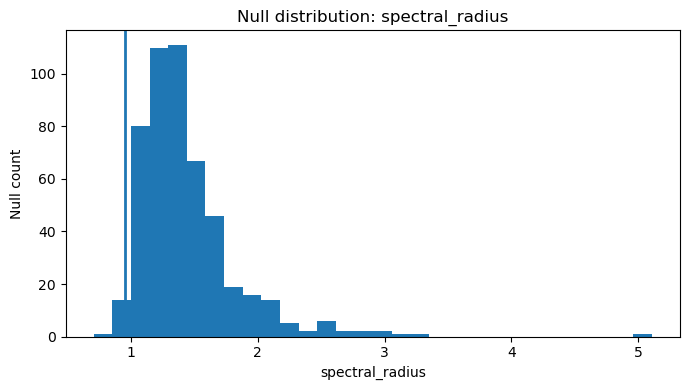

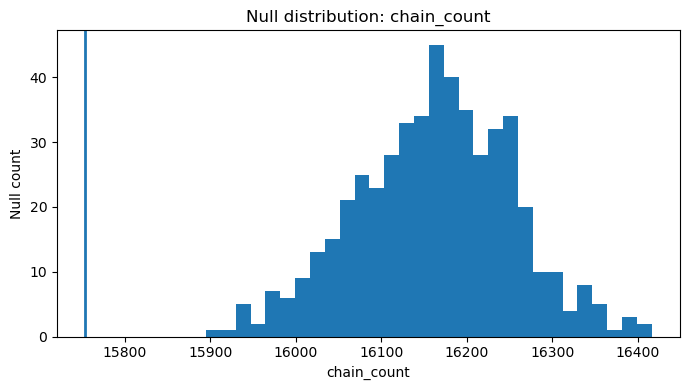

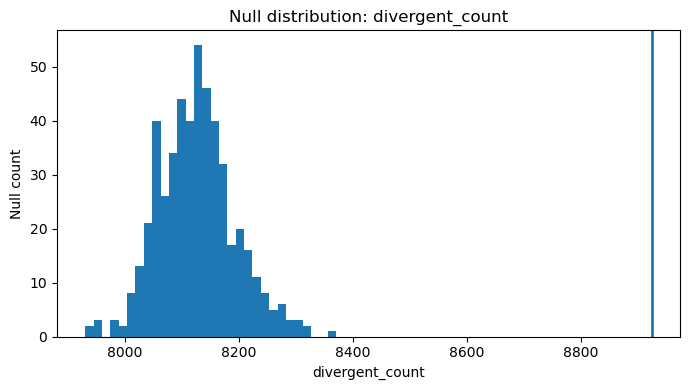

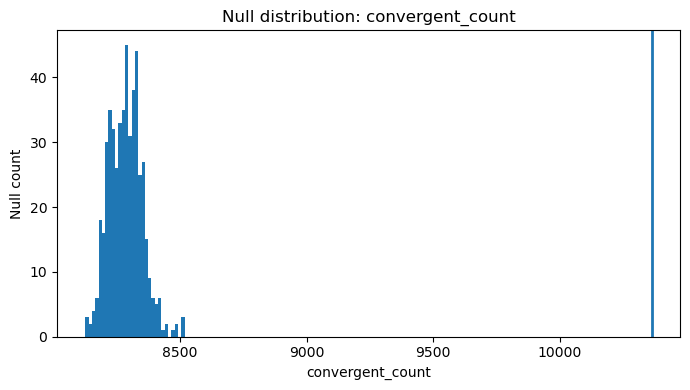

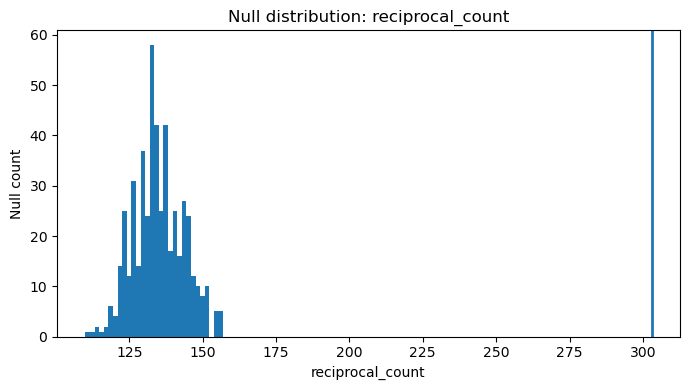

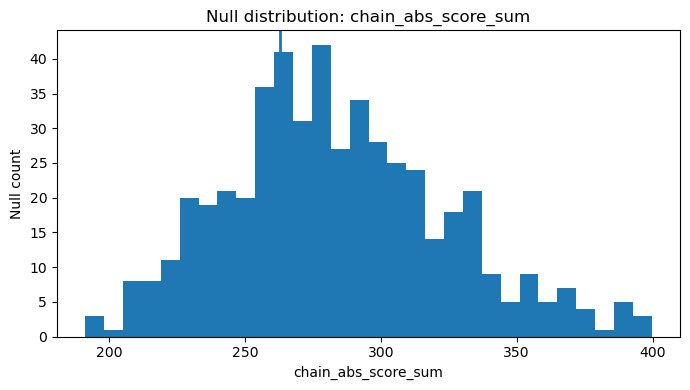

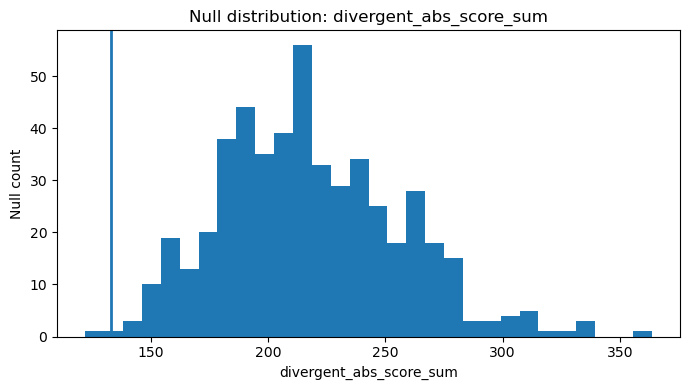

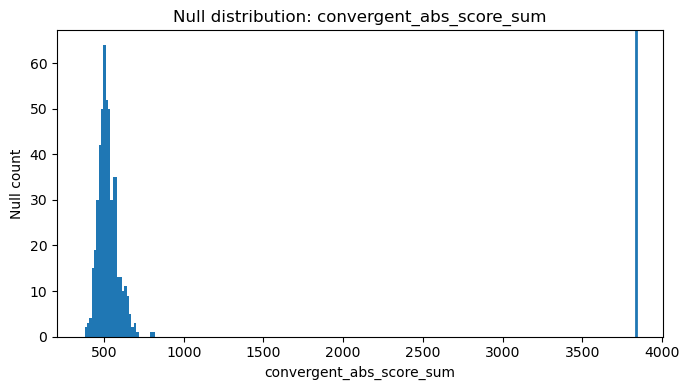

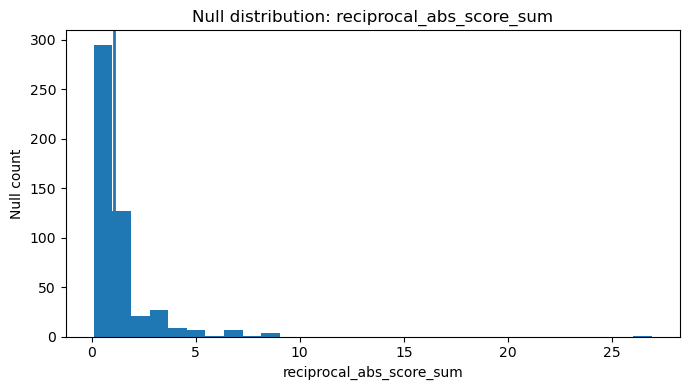

In [18]:
# Section 5.1 Plot observed values against null distributions

metrics_to_plot = [
    "spectral_radius",
    "chain_count",
    "divergent_count",
    "convergent_count",
    "reciprocal_count",
    "chain_abs_score_sum",
    "divergent_abs_score_sum",
    "convergent_abs_score_sum",
    "reciprocal_abs_score_sum",
]

for metric in metrics_to_plot:
    observed_value = observed_null_reference[metric]

    plt.figure(figsize=(7, 4))
    plt.hist(df_null[metric], bins=30)
    plt.axvline(observed_value, linewidth=2)
    plt.xlabel(metric)
    plt.ylabel("Null count")
    plt.title(f"Null distribution: {metric}")
    plt.tight_layout()
    plt.show()

In [19]:
# Section 5.2 Save Section 5 outputs

df_null.to_csv(OUTPUT_DIR / "section5_null_ensemble.csv", index=False)
null_comparison.to_csv(OUTPUT_DIR / "section5_null_comparison.csv", index=False)

print(f"Saved Section 5 outputs to: {OUTPUT_DIR}")

Saved Section 5 outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


## Intepretations

**1. Best-case Shao extension**
-  λ₁ above null
-  chain_count or chain_abs_score_sum above null
-  dominant eigenvector concentrated in EC/CA3 excitatory cells

Narrative:
> Structured excitatory chain motifs likely generate the leading recurrent mode in this empirical hippocampal network.

**2. Alternate A**
-  λ₁ normal
-  reciprocal high
-  convergent/divergent high

Narrative:
> This biological subset is organized more for integration/distribution loops than chain-driven global amplification.

**3. Alternate B**
-  no motif enrichment
-  λ₁ still high

Narrative:
> Large-scale block connectivity or hub structure dominates dynamics more than local motifs.

In [20]:
# Section 5 Auto-interpretation

def interpret_section5(null_comparison):
    lines = []
    lines.append("## Section 5 Interpretation: Null / Random Controls\n")

    strong = null_comparison[null_comparison["z_score"].abs() >= 3].copy()
    moderate = null_comparison[
        (null_comparison["z_score"].abs() >= 2) & 
        (null_comparison["z_score"].abs() < 3)
    ].copy()

    if len(strong) > 0:
        lines.append("Strong deviations from the block-preserving null model were detected:")
        for _, row in strong.sort_values("z_score", key=lambda s: s.abs(), ascending=False).iterrows():
            direction = "above" if row["z_score"] > 0 else "below"
            lines.append(
                f"- `{row['metric']}` is {direction} null expectation "
                f"(z = {row['z_score']:.2f}, p ≈ {row['empirical_p_two_sided']:.4f})."
            )
    else:
        lines.append("No metrics show strong deviation from the null model using |z| ≥ 3.")

    if len(moderate) > 0:
        lines.append("\nModerate deviations were detected:")
        for _, row in moderate.sort_values("z_score", key=lambda s: s.abs(), ascending=False).iterrows():
            direction = "above" if row["z_score"] > 0 else "below"
            lines.append(
                f"- `{row['metric']}` is {direction} null expectation "
                f"(z = {row['z_score']:.2f})."
            )

    if "chain_abs_score_sum" in null_comparison["metric"].values:
        chain_row = null_comparison.loc[
            null_comparison["metric"].eq("chain_abs_score_sum")
        ].iloc[0]

        lines.append(
            f"\nChain absolute motif strength has z = {chain_row['z_score']:.2f}."
        )

        if chain_row["z_score"] >= 3:
            lines.append("This supports a Shao-style interpretation: chain motif strength is enriched beyond block-level wiring constraints.")
        elif chain_row["z_score"] <= -3:
            lines.append("Chain motif strength is lower than expected, suggesting the empirical matrix avoids strong chain-like amplification.")
        else:
            lines.append("Chain motif strength is not strongly enriched under this null model.")

    lines.append(
        "\nThis section tells us whether observed motifs and spectral features exceed what would be expected from E/I block structure alone. In other words, it checks whether the network is structured, not merely dense."
    )

    return "\n".join(lines)


section5_interpretation = interpret_section5(null_comparison)

print(section5_interpretation)

with open(OUTPUT_DIR / "section5_auto_interpretation.md", "w", encoding="utf-8") as f:
    f.write(section5_interpretation)

## Section 5 Interpretation: Null / Random Controls

Strong deviations from the block-preserving null model were detected:
- `convergent_abs_score_sum` is above null expectation (z = 54.88, p ≈ 0.0020).
- `convergent_score_sum` is above null expectation (z = 54.88, p ≈ 0.0020).
- `convergent_count` is above null expectation (z = 32.22, p ≈ 0.0020).
- `reciprocal_count` is above null expectation (z = 19.67, p ≈ 0.0020).
- `divergent_count` is above null expectation (z = 11.94, p ≈ 0.0020).
- `chain_count` is below null expectation (z = -4.47, p ≈ 0.0020).

Moderate deviations were detected:
- `divergent_score_sum` is below null expectation (z = -2.32).
- `divergent_abs_score_sum` is below null expectation (z = -2.22).

Chain absolute motif strength has z = -0.52.
Chain motif strength is not strongly enriched under this null model.

This section tells us whether observed motifs and spectral features exceed what would be expected from E/I block structure alone. In other words, it checks w

---
# Section 6. Low-Rank Approximation and Effective Connectivity Matrix

Large recurrent networks often contain dynamics that are dominated by only a few structured modes. Instead of analyzing all 72 dimensions equally, we approximate the connectivity matrix using its leading eigenmodes or singular components.

A low-rank approximation asks whether:

\[
J \approx \sum_{r=1}^{k} \lambda_r u_r v_r^T
\]

for small \(k\), meaning a handful of dominant patterns explain most functional structure.

This is directly relevant to Shao et al., who showed that motif structure can generate outlier eigenvalues and therefore low-dimensional dynamical modes that strongly influence responses.

We also compute an **effective connectivity matrix**, where the full network is coarse-grained into excitatory and inhibitory populations:

$$ J_{\text{eff}} = \begin{bmatrix}
J_{EE} & J_{EI} \\
J_{IE} & J_{II}
\end{bmatrix}$$

using average block interactions or motif-corrected block terms.

This allows us to compare three descriptions of the same system:

1. Full 72-node empirical network  
2. Low-rank spectral approximation  
3. Population-level E/I effective network

If these simplified models reproduce responses or stability, then dominant structure is low-dimensional. If not, fine-scale motifs carry essential information.

**References**

Shao Y et al. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025.

Mastrogiuseppe F, Ostojic S. *Linking connectivity, dynamics, and computations in low-rank recurrent neural networks.* Neuron. 2018.

Horn RA, Johnson CR. *Matrix Analysis.* Cambridge University Press.

In [21]:
# Section 6. Low-rank approximation and effective E/I connectivity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use normalized matrix from Section 2
J_full = J.copy()
A = J_full.to_numpy(dtype=float)
nodes = list(J_full.index)
n = A.shape[0]

# -----------------------------
# 6.1 Eigen-decomposition summary
# -----------------------------

eigvals, eigvecs = np.linalg.eig(A)

eig_order = np.argsort(np.abs(eigvals))[::-1]
eigvals_sorted = eigvals[eig_order]
eigvecs_sorted = eigvecs[:, eig_order]

eig_rank_summary = pd.DataFrame({
    "rank": np.arange(1, n + 1),
    "eig_index": eig_order,
    "real": eigvals_sorted.real,
    "imag": eigvals_sorted.imag,
    "abs": np.abs(eigvals_sorted),
    "angle_rad": np.angle(eigvals_sorted),
})

display(eig_rank_summary.head(10))

,rank,eig_index,real,imag,abs,angle_rad
0,1,0,0.950000,0.000000,0.950000,0.000000
1,2,3,-0.722125,0.000000,0.722125,3.141593
2,3,1,0.113341,0.666940,0.676503,1.402463
3,4,2,0.113341,-0.666940,0.676503,-1.402463
4,5,4,-0.557614,0.000000,0.557614,3.141593
5,6,6,0.371521,-0.193811,0.419035,-0.480833
6,7,5,0.371521,0.193811,0.419035,0.480833
7,8,7,-0.345221,0.000000,0.345221,3.141593
8,9,8,-0.061483,0.188758,0.198519,1.885684
9,10,9,-0.061483,-0.188758,0.198519,-1.885684


,rank,singular_value,variance_fraction,cumulative_variance_fraction
0,1,19.700004,0.762513,0.762513
1,2,8.042424,0.127083,0.889596
2,3,6.356796,0.079395,0.968991
3,4,2.933780,0.016911,0.985902
4,5,1.695983,0.005651,0.991553
5,6,1.247732,0.003059,0.994612
6,7,1.139549,0.002551,0.997163
7,8,1.028170,0.002077,0.999240
8,9,0.466952,0.000428,0.999669
9,10,0.249119,0.000122,0.999791


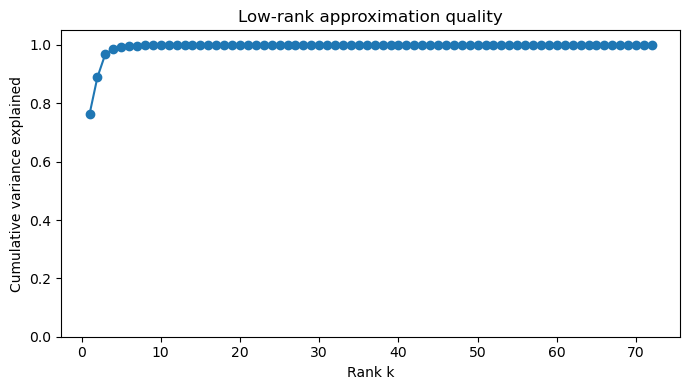

In [22]:
# -----------------------------
# 6.2 SVD-based low-rank approximation
# -----------------------------

U, s, Vt = np.linalg.svd(A, full_matrices=False)

svd_summary = pd.DataFrame({
    "rank": np.arange(1, len(s) + 1),
    "singular_value": s,
    "variance_fraction": s**2 / np.sum(s**2),
    "cumulative_variance_fraction": np.cumsum(s**2) / np.sum(s**2),
})

display(svd_summary.head(15))

plt.figure(figsize=(7, 4))
plt.plot(svd_summary["rank"], svd_summary["cumulative_variance_fraction"], marker="o")
plt.xlabel("Rank k")
plt.ylabel("Cumulative variance explained")
plt.title("Low-rank approximation quality")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [23]:
# -----------------------------
# 6.3 Reconstruct low-rank matrices
# -----------------------------

def svd_low_rank_matrix(U, s, Vt, k, index, columns):
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    return pd.DataFrame(A_k, index=index, columns=columns)


low_rank_versions = {}

for k in [1, 2, 3, 5, 10]:
    low_rank_versions[f"J_rank{k}"] = svd_low_rank_matrix(
        U, s, Vt, k, J_full.index, J_full.columns
    )

low_rank_error_rows = []

fro_full = np.linalg.norm(A, ord="fro")

for name, J_k in low_rank_versions.items():
    A_k = J_k.to_numpy(dtype=float)
    error = np.linalg.norm(A - A_k, ord="fro")
    rel_error = error / fro_full
    
    low_rank_error_rows.append({
        "matrix": name,
        "rank": int(name.replace("J_rank", "")),
        "fro_error": error,
        "relative_fro_error": rel_error,
        "variance_explained": 1 - rel_error**2,
        "spectral_radius": float(np.max(np.abs(np.linalg.eigvals(A_k)))),
    })

low_rank_error = pd.DataFrame(low_rank_error_rows)

display(low_rank_error)

,matrix,rank,fro_error,relative_fro_error,variance_explained,spectral_radius
0,J_rank1,1,10.994184,0.487327,0.762513,0.304374
1,J_rank2,2,7.496099,0.332271,0.889596,0.822591
2,J_rank3,3,3.972739,0.176095,0.968991,0.880757
3,J_rank5,5,2.073458,0.091908,0.991553,0.957893
4,J_rank10,10,0.326469,0.014471,0.999791,1.009976


In [24]:
# -----------------------------
# 6.4 Effective 2 x 2 E/I connectivity matrix
# -----------------------------
# Convention: J.loc[target, source]
# Targets are receiving populations; sources are sending populations.

def block_stats(block):
    arr = block.to_numpy(dtype=float)
    nonzero = arr[arr != 0]
    return {
        "mean_nonzero_weight": float(np.mean(nonzero)) if nonzero.size else 0.0,
        "total_weight": float(np.sum(arr)),
        "density": float(np.count_nonzero(arr) / arr.size) if arr.size else np.nan,
    }


effective_blocks = [
    ("Target_E", "Source_E", J_full.loc[E_nodes, E_nodes]),
    ("Target_E", "Source_I", J_full.loc[E_nodes, I_nodes]),
    ("Target_I", "Source_E", J_full.loc[I_nodes, E_nodes]),
    ("Target_I", "Source_I", J_full.loc[I_nodes, I_nodes]),
]

J_eff_summary = pd.DataFrame(
    {
        "target": target,
        "source": source,
        **block_stats(block),
    }
    for target, source, block in effective_blocks
)

def effective_matrix(metric):
    table = J_eff_summary.pivot(index="target", columns="source", values=metric)
    table = table.loc[["Target_E", "Target_I"], ["Source_E", "Source_I"]]
    table.index.name = "target"
    table.columns.name = "source"
    return table


J_eff_mean = effective_matrix("mean_nonzero_weight")
J_eff_sum = effective_matrix("total_weight")
J_eff_density = effective_matrix("density")

print("Effective connectivity by E/I block (J[target, source])")
display(J_eff_summary)


Effective connectivity by E/I block (J[target, source])


target,source,mean_nonzero_weight,total_weight,density
Target_E,Source_E,0.152862,44.635744,0.372449
Target_E,Source_I,0.624800,129.958335,0.168831
Target_I,Source_E,-0.005598,-0.638145,0.092532
Target_I,Source_I,-0.003165,-1.509681,0.246384


Eigenvalues of 2x2 effective E/I matrix:


,eig_index,real,imag,abs
0,0,0.125727,0.0,0.125727
1,1,0.023970,0.0,0.023970


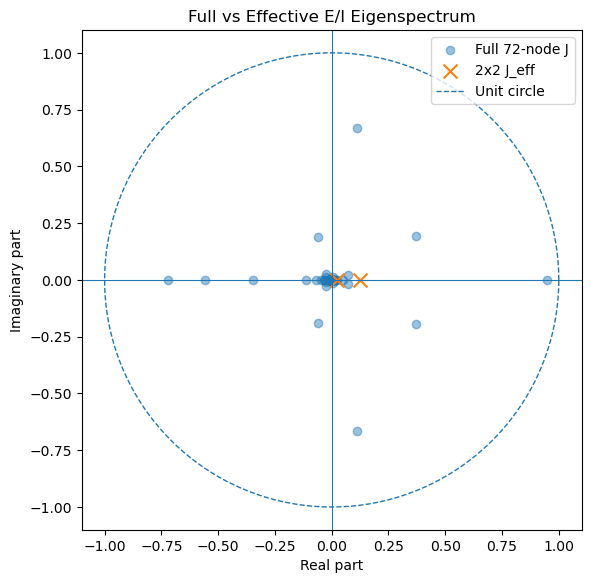

In [25]:
# -----------------------------
# 6.5 Compare eigenspectrum of full matrix vs effective E/I matrix
# -----------------------------

eig_eff = np.linalg.eigvals(J_eff_mean.to_numpy(dtype=float))

eff_summary = pd.DataFrame({
    "eig_index": np.arange(len(eig_eff)),
    "real": eig_eff.real,
    "imag": eig_eff.imag,
    "abs": np.abs(eig_eff),
}).sort_values("abs", ascending=False)

print("Eigenvalues of 2x2 effective E/I matrix:")
display(eff_summary)

plt.figure(figsize=(6, 6))
plt.scatter(eigvals.real, eigvals.imag, alpha=0.45, label="Full 72-node J")
plt.scatter(eig_eff.real, eig_eff.imag, marker="x", s=100, label="2x2 J_eff")

theta = np.linspace(0, 2*np.pi, 500)
plt.plot(np.cos(theta), np.sin(theta), linestyle="--", linewidth=1, label="Unit circle")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Full vs Effective E/I Eigenspectrum")
plt.gca().set_aspect("equal", adjustable="box")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [26]:
# -----------------------------
# 6.6 Save Section 6 outputs
# -----------------------------

eig_rank_summary.to_csv(OUTPUT_DIR / "section6_eigen_rank_summary.csv", index=False)
svd_summary.to_csv(OUTPUT_DIR / "section6_svd_summary.csv", index=False)
low_rank_error.to_csv(OUTPUT_DIR / "section6_low_rank_error.csv", index=False)

J_eff_mean.to_csv(OUTPUT_DIR / "section6_J_eff_mean.csv")
J_eff_sum.to_csv(OUTPUT_DIR / "section6_J_eff_sum.csv")
J_eff_density.to_csv(OUTPUT_DIR / "section6_J_eff_density.csv")
J_eff_summary.to_csv(OUTPUT_DIR / "section6_J_eff_summary.csv", index=False)

for name, J_k in low_rank_versions.items():
    J_k.to_csv(OUTPUT_DIR / f"section6_{name}.csv")

print(f"Saved Section 6 outputs to: {OUTPUT_DIR}")


Saved Section 6 outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


In [27]:
# Section 6 Auto-interpretation

def interpret_section6(svd_summary, low_rank_error, J_eff_mean, eff_summary):
    lines = []
    lines.append("## Section 6 Interpretation: Low-Rank Approximation and Effective Connectivity\n")

    for k in [1, 2, 3, 5, 10]:
        row = low_rank_error.loc[low_rank_error["rank"].eq(k)]
        if len(row) > 0:
            ve = float(row["variance_explained"].iloc[0])
            lines.append(f"Rank-{k} approximation explains approximately {ve:.2%} of matrix structure.")

    rank3 = low_rank_error.loc[low_rank_error["rank"].eq(3)]
    if len(rank3) > 0:
        ve3 = float(rank3["variance_explained"].iloc[0])
        if ve3 >= 0.7:
            lines.append("\nThe matrix is strongly low-dimensional: a few modes capture most structure.")
        elif ve3 >= 0.4:
            lines.append("\nThe matrix has moderate low-dimensional structure, but higher-rank details remain important.")
        else:
            lines.append("\nThe matrix is not well captured by only a few modes; fine-scale structure likely matters.")

    lines.append("\nEffective E/I connectivity based on mean nonzero block weights (source -> target):")
    for target in J_eff_mean.index:
        for source in J_eff_mean.columns:
            lines.append(f"- {source} → {target}: {J_eff_mean.loc[target, source]:.4f}")

    dominant_eff = eff_summary.sort_values("abs", ascending=False).iloc[0]
    lines.append(
        f"\nThe dominant eigenvalue of the 2x2 effective E/I matrix has magnitude {dominant_eff['abs']:.4f}."
    )

    lines.append(
        "\nIf the 2x2 effective matrix captures the same stability pattern as the full 72-node matrix, then population-level E/I structure explains much of the dynamics. If not, motifs and node-specific organization carry essential information. Because naturally, biology rarely chooses the cheaper explanation."
    )

    return "\n".join(lines)


section6_interpretation = interpret_section6(
    svd_summary=svd_summary,
    low_rank_error=low_rank_error,
    J_eff_mean=J_eff_mean,
    eff_summary=eff_summary
)

print(section6_interpretation)

with open(OUTPUT_DIR / "section6_auto_interpretation.md", "w", encoding="utf-8") as f:
    f.write(section6_interpretation)


## Section 6 Interpretation: Low-Rank Approximation and Effective Connectivity

Rank-1 approximation explains approximately 76.25% of matrix structure.
Rank-2 approximation explains approximately 88.96% of matrix structure.
Rank-3 approximation explains approximately 96.90% of matrix structure.
Rank-5 approximation explains approximately 99.16% of matrix structure.
Rank-10 approximation explains approximately 99.98% of matrix structure.

The matrix is strongly low-dimensional: a few modes capture most structure.

Effective E/I connectivity based on mean nonzero block weights (source -> target):
- Source_E → Target_E: 0.1529
- Source_I → Target_E: 0.6248
- Source_E → Target_I: -0.0056
- Source_I → Target_I: -0.0032

The dominant eigenvalue of the 2x2 effective E/I matrix has magnitude 0.1257.

If the 2x2 effective matrix captures the same stability pattern as the full 72-node matrix, then population-level E/I structure explains much of the dynamics. If not, motifs and node-specific orga

---
# Section 7. Perturbation Response Analysis

Connectivity alone does not reveal how a circuit behaves when stimulated. To connect structure to function, we compute linear responses to external inputs using:

\[
r^\* = (I - J)^{-1} I_{\text{ext}}
\]

where \(I_{\text{ext}}\) is an imposed perturbation and \(r^\*\) is the steady-state response.

We test several biologically relevant inputs:

1. Broad excitation to excitatory nodes  
2. Broad excitation to inhibitory nodes  
3. Single-node stimulation of high-loading eigenmode nodes  
4. Regional stimulation (e.g., EC, CA3, DG, CA1)

We then measure:

- mean E response  
- mean I response  
- nodewise amplification  
- regional propagation  
- paradoxical inhibitory responses

A paradoxical response occurs when increasing input to inhibitory neurons decreases their steady-state activity because recurrent feedback suppresses them. Shao et al. showed that such behavior can arise not only from average E/I balance, but also from motif-induced structure.

This section therefore tests whether the empirical hippocampal matrix behaves like a classical inhibition-stabilized network, a motif-dominated network, or a hybrid of both.

**References**

Tsodyks MV et al. *Paradoxical effects of external modulation of inhibitory interneurons.* J Neurosci. 1997.

Shao Y et al. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025.

In [28]:
# Section 7. Perturbation response analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses:
# J = normalized full matrix
# E_nodes, I_nodes = node lists from Section 1
# OUTPUT_DIR = output folder

J_resp = J.copy()
A = J_resp.to_numpy(dtype=float)
nodes = list(J_resp.index)
n = len(nodes)

I_mat = np.eye(n)

# Check stability before inverse. Because linear algebra enjoys punishing optimism.
rho = np.max(np.abs(np.linalg.eigvals(A)))
print(f"Spectral radius of J: {rho:.4f}")

if rho >= 1:
    print("Warning: spectral radius >= 1. Linear steady-state response may be unstable.")

R = np.linalg.inv(I_mat - A)  # response matrix: r* = (I - J)^-1 I_ext

response_matrix = pd.DataFrame(R, index=nodes, columns=nodes)

Spectral radius of J: 0.9500


In [29]:
# Section 7.1 Define perturbation vectors

def make_input_vector(target_nodes, amplitude=1.0):
    """
    Create external input vector where selected nodes receive amplitude.
    """
    x = pd.Series(0.0, index=nodes)
    x.loc[target_nodes] = amplitude
    return x


inputs = {
    "input_all_E": make_input_vector(E_nodes, amplitude=1.0),
    "input_all_I": make_input_vector(I_nodes, amplitude=1.0),
}

# Optional: stimulate top dominant-mode nodes if df_dom exists from Section 3
if "df_dom" in globals():
    top_mode_nodes = df_dom.head(5)["node"].tolist()
    inputs["input_top5_dominant_mode_nodes"] = make_input_vector(top_mode_nodes, amplitude=1.0)

# Optional: regional stimulation based on simple name matching
regions = ["EC", "MEC", "LEC", "DG", "CA3", "CA2", "CA1"]

for region in regions:
    region_nodes = [node for node in nodes if region in node]
    if region_nodes:
        inputs[f"input_region_{region}"] = make_input_vector(region_nodes, amplitude=1.0)

print("Input conditions:")
for name, vec in inputs.items():
    print(f"{name}: {int((vec != 0).sum())} stimulated nodes")

Input conditions:
input_all_E: 28 stimulated nodes
input_all_I: 44 stimulated nodes
input_top5_dominant_mode_nodes: 5 stimulated nodes
input_region_EC: 21 stimulated nodes
input_region_MEC: 10 stimulated nodes
input_region_LEC: 3 stimulated nodes
input_region_DG: 13 stimulated nodes
input_region_CA3: 10 stimulated nodes
input_region_CA2: 4 stimulated nodes
input_region_CA1: 24 stimulated nodes


In [30]:
# Section 7.2 Compute steady-state responses

response_records = []
node_response_tables = {}

for input_name, input_vec in inputs.items():
    r = R @ input_vec.to_numpy(dtype=float)

    response_df = pd.DataFrame({
        "node": nodes,
        "node_type": node_types.loc[nodes, "node_type"].values,
        "input": input_vec.values,
        "response": r,
        "abs_response": np.abs(r),
    })

    node_response_tables[input_name] = response_df

    mean_E = response_df.loc[response_df["node_type"].eq("E"), "response"].mean()
    mean_I = response_df.loc[response_df["node_type"].eq("I"), "response"].mean()

    sum_E = response_df.loc[response_df["node_type"].eq("E"), "response"].sum()
    sum_I = response_df.loc[response_df["node_type"].eq("I"), "response"].sum()

    response_records.append({
        "input_condition": input_name,
        "n_stimulated": int((input_vec != 0).sum()),
        "mean_E_response": mean_E,
        "mean_I_response": mean_I,
        "sum_E_response": sum_E,
        "sum_I_response": sum_I,
        "max_abs_node_response": response_df["abs_response"].max(),
        "top_response_node": response_df.sort_values("abs_response", ascending=False).iloc[0]["node"],
    })

response_summary = pd.DataFrame(response_records)

display(response_summary)

,input_condition,n_stimulated,mean_E_response,mean_I_response,sum_E_response,sum_I_response,max_abs_node_response,top_response_node
0,input_all_E,28,64.689709,-1.359745,1811.311849,-59.828795,416.939565,EC LI II Multipolar Pyramidal
1,input_all_I,44,116.372249,-1.549305,3258.422962,-68.169425,738.710563,EC LI II Multipolar Pyramidal
2,input_top5_dominant_mode_nodes,5,2.259128,-0.042493,63.255580,-1.869706,16.172765,EC LI II Multipolar Pyramidal
3,input_region_EC,21,45.302123,-0.911665,1268.459442,-40.113279,296.352828,EC LI II Multipolar Pyramidal
4,input_region_MEC,10,17.115837,-0.325470,479.243449,-14.320695,112.412786,EC LI II Multipolar Pyramidal
5,input_region_LEC,3,8.658204,-0.181765,242.429709,-7.997658,55.642942,EC LI II Multipolar Pyramidal
6,input_region_DG,13,42.661223,-0.702660,1194.514251,-30.917039,270.924752,EC LI II Multipolar Pyramidal
7,input_region_CA3,10,4.820382,0.056834,134.970694,2.500711,31.352041,EC LI II Multipolar Pyramidal
8,input_region_CA2,4,10.887437,-0.148135,304.848241,-6.517931,68.718203,EC LI II Multipolar Pyramidal
9,input_region_CA1,24,77.390792,-1.203425,2166.942184,-52.950682,488.302304,EC LI II Multipolar Pyramidal


In [31]:
# Section 7.3 Check for paradoxical inhibitory response

# Paradoxical response here:
# increased input to I nodes produces a negative mean response among I nodes.

paradox_row = response_summary[
    response_summary["input_condition"].eq("input_all_I")
].copy()

if len(paradox_row) == 1:
    mean_I_response = float(paradox_row["mean_I_response"].iloc[0])

    if mean_I_response < 0:
        print("Paradoxical inhibitory response detected.")
        print(f"Mean I response to I input = {mean_I_response:.4f}")
    else:
        print("No paradoxical inhibitory response under broad I stimulation.")
        print(f"Mean I response to I input = {mean_I_response:.4f}")
else:
    print("Could not evaluate paradoxical response because input_all_I was not found.")

Paradoxical inhibitory response detected.
Mean I response to I input = -1.5493


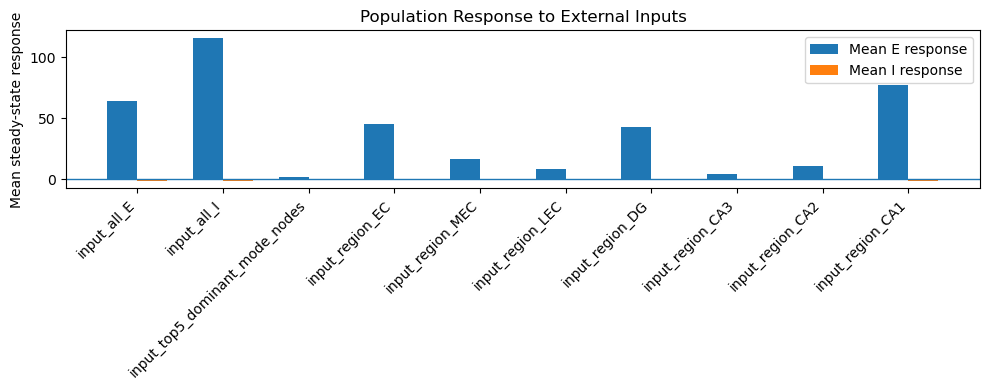

In [32]:
# Section 7.4 Plot population-level responses

plot_df = response_summary.copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width/2, plot_df["mean_E_response"], width, label="Mean E response")
plt.bar(x + width/2, plot_df["mean_I_response"], width, label="Mean I response")

plt.axhline(0, linewidth=1)
plt.xticks(x, plot_df["input_condition"], rotation=45, ha="right")
plt.ylabel("Mean steady-state response")
plt.title("Population Response to External Inputs")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

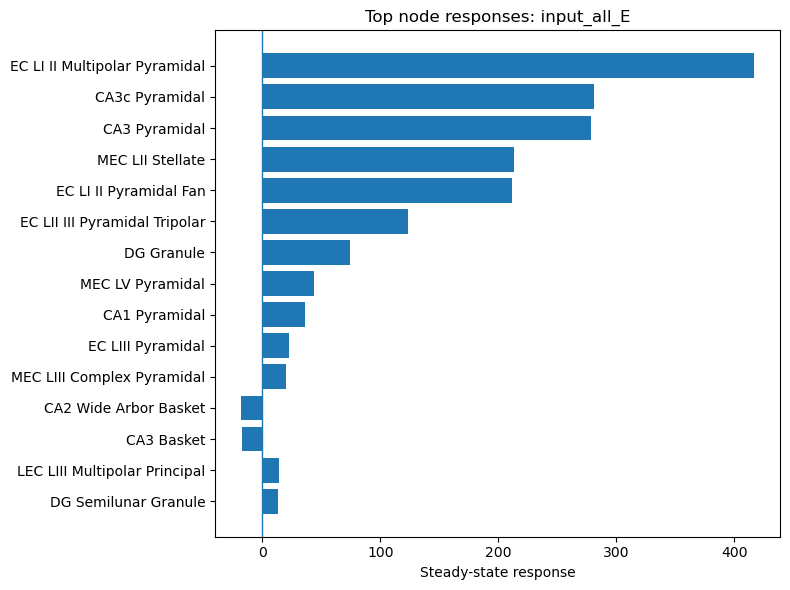

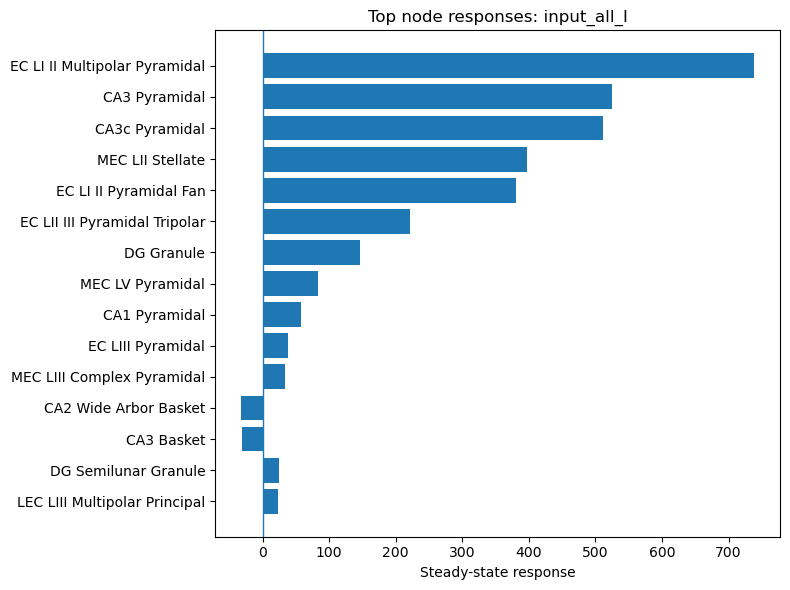

In [33]:
# Section 7.5 Plot top node responses for broad E and broad I input

for input_name in ["input_all_E", "input_all_I"]:
    if input_name not in node_response_tables:
        continue

    plot_df = (
        node_response_tables[input_name]
        .sort_values("abs_response", ascending=False)
        .head(15)
        .iloc[::-1]
    )

    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["node"], plot_df["response"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Steady-state response")
    plt.title(f"Top node responses: {input_name}")
    plt.tight_layout()
    plt.show()

In [34]:
# Section 7.6 Save Section 7 outputs

response_matrix.to_csv(OUTPUT_DIR / "section7_response_matrix.csv")
response_summary.to_csv(OUTPUT_DIR / "section7_response_summary.csv", index=False)

for input_name, table in node_response_tables.items():
    table.to_csv(OUTPUT_DIR / f"section7_node_responses_{input_name}.csv", index=False)

print(f"Saved Section 7 outputs to: {OUTPUT_DIR}")

Saved Section 7 outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


In [35]:
# Section 7 Auto-interpretation

def interpret_section7(response_summary):
    lines = []
    lines.append("## Section 7 Interpretation: Perturbation Response Analysis\n")

    strongest = response_summary.sort_values("max_abs_node_response", ascending=False).iloc[0]
    lines.append(
        f"The input condition producing the largest single-node response was "
        f"`{strongest['input_condition']}`, with maximum absolute response "
        f"{strongest['max_abs_node_response']:.4f} at `{strongest['top_response_node']}`."
    )

    if "input_all_E" in response_summary["input_condition"].values:
        row_E = response_summary.loc[
            response_summary["input_condition"].eq("input_all_E")
        ].iloc[0]
        lines.append(
            f"\nBroad E stimulation produced mean E response {row_E['mean_E_response']:.4f} "
            f"and mean I response {row_E['mean_I_response']:.4f}."
        )

    if "input_all_I" in response_summary["input_condition"].values:
        row_I = response_summary.loc[
            response_summary["input_condition"].eq("input_all_I")
        ].iloc[0]
        lines.append(
            f"\nBroad I stimulation produced mean E response {row_I['mean_E_response']:.4f} "
            f"and mean I response {row_I['mean_I_response']:.4f}."
        )

        if row_I["mean_I_response"] < 0:
            lines.append(
                "This is a paradoxical inhibitory response: increasing input to inhibitory nodes decreases their steady-state inhibitory activity."
            )
        else:
            lines.append(
                "This is not a paradoxical inhibitory response under the current normalization and perturbation setup."
            )

    regional_rows = response_summary[
        response_summary["input_condition"].str.contains("input_region_", regex=False)
    ]

    if len(regional_rows) > 0:
        top_region = regional_rows.sort_values("max_abs_node_response", ascending=False).iloc[0]
        lines.append(
            f"\nAmong regional perturbations, `{top_region['input_condition']}` produced the strongest node-level response."
        )

    lines.append(
        "\nThis section links structure to function by asking how the recurrent network transforms external input into steady-state activity. This is the practical version of staring at a matrix until it confesses."
    )

    return "\n".join(lines)


section7_interpretation = interpret_section7(response_summary)

print(section7_interpretation)

with open(OUTPUT_DIR / "section7_auto_interpretation.md", "w", encoding="utf-8") as f:
    f.write(section7_interpretation)

## Section 7 Interpretation: Perturbation Response Analysis

The input condition producing the largest single-node response was `input_all_I`, with maximum absolute response 738.7106 at `EC LI II Multipolar Pyramidal`.

Broad E stimulation produced mean E response 64.6897 and mean I response -1.3597.

Broad I stimulation produced mean E response 116.3722 and mean I response -1.5493.
This is a paradoxical inhibitory response: increasing input to inhibitory nodes decreases their steady-state inhibitory activity.

Among regional perturbations, `input_region_CA1` produced the strongest node-level response.

This section links structure to function by asking how the recurrent network transforms external input into steady-state activity. This is the practical version of staring at a matrix until it confesses.


---
# Section 8. Motif Removal / Motif Scrambling Experiment

Correlation does not imply causation, and neither does a pretty eigenspectrum. If chain motifs correlate with strong positive modes, we still need to test whether they are responsible.

We create altered versions of the empirical matrix in which selected motifs are removed, weakened, or randomized while preserving as much of the remaining network structure as possible.

Examples include:

1. Chain-preserving randomization  
2. Chain-destroying rewiring  
3. Reciprocal-pair removal  
4. Convergent/divergent scrambling  
5. E/E block-preserved randomization

For each manipulated matrix we recompute:

- dominant eigenvalue  
- eigenspectrum  
- low-rank approximation quality  
- effective connectivity  
- perturbation responses  
- paradoxical response signatures

If removing chain motifs substantially reduces the leading positive mode or changes system responses, that supports the central claim of Shao et al. that motifs can dominate dynamics beyond average E/I statistics.

If little changes, then the empirical network may be governed more by block connectivity or distributed redundancy than by any single motif class. Science allows disappointment.

**References**

Shao Y et al. *Impact of Local Connectivity Patterns on Excitatory-Inhibitory Network Dynamics.* PRX Life. 2025.

Sporns O, Kötter R. *Motifs in brain networks.* PLoS Biol. 2004.

In [36]:
# Section 8. Motif removal / motif scrambling experiment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Uses:
# J, df_motifs, E_nodes, I_nodes, node_types, OUTPUT_DIR

J_base = J.copy()
A_base = J_base.to_numpy(dtype=float)
nodes = list(J_base.index)
node_to_idx = {node: i for i, node in enumerate(nodes)}
n = len(nodes)

rng = np.random.default_rng(751)

# Convention:
# A[target, source] = source -> target


def parse_edge(edge_string):
    """Parse edge strings like 'A -> B' into source, target."""
    source, target = edge_string.split(" -> ")
    return source.strip(), target.strip()


def spectral_radius_array(A):
    return float(np.max(np.abs(np.linalg.eigvals(A))))


def dominant_eigenvalue_array(A):
    eigvals = np.linalg.eigvals(A)
    return eigvals[np.argmax(np.abs(eigvals))]


def stable_response_summary(A, nodes, E_nodes, I_nodes):
    """
    Compute broad E and broad I perturbation responses.
    If matrix is unstable or singular, return NaNs.
    """
    rho = spectral_radius_array(A)

    try:
        R = np.linalg.inv(np.eye(A.shape[0]) - A)
    except np.linalg.LinAlgError:
        return {
            "rho": rho,
            "mean_E_to_E_input": np.nan,
            "mean_I_to_E_input": np.nan,
            "mean_E_to_I_input": np.nan,
            "mean_I_to_I_input": np.nan,
            "paradoxical_I_response": np.nan,
        }

    E_idx = [node_to_idx[x] for x in E_nodes]
    I_idx = [node_to_idx[x] for x in I_nodes]

    input_E = np.zeros(A.shape[0])
    input_E[E_idx] = 1.0

    input_I = np.zeros(A.shape[0])
    input_I[I_idx] = 1.0

    r_E = R @ input_E
    r_I = R @ input_I

    mean_E_to_E_input = float(np.mean(r_E[E_idx]))
    mean_I_to_E_input = float(np.mean(r_E[I_idx]))

    mean_E_to_I_input = float(np.mean(r_I[E_idx]))
    mean_I_to_I_input = float(np.mean(r_I[I_idx]))

    return {
        "rho": rho,
        "mean_E_to_E_input": mean_E_to_E_input,
        "mean_I_to_E_input": mean_I_to_E_input,
        "mean_E_to_I_input": mean_E_to_I_input,
        "mean_I_to_I_input": mean_I_to_I_input,
        "paradoxical_I_response": bool(mean_I_to_I_input < 0),
    }


def count_motifs_simple(A):
    """
    Reuse fast count logic from Section 5 if available.
    Otherwise define minimal counts here.
    """
    if "count_motif_types_fast" in globals():
        return count_motif_types_fast(A)

    B = (A != 0).astype(int)
    np.fill_diagonal(B, 0)
    S = B.T

    n = A.shape[0]

    chain = 0
    for j in range(n):
        sources = np.where(S[:, j] != 0)[0]
        targets = np.where(S[j, :] != 0)[0]
        for i in sources:
            for k in targets:
                if i != j and j != k and i != k:
                    chain += 1

    divergent = 0
    for k in range(n):
        outdeg = int(np.sum(S[k, :] != 0))
        divergent += outdeg * (outdeg - 1) // 2

    convergent = 0
    for k in range(n):
        indeg = int(np.sum(S[:, k] != 0))
        convergent += indeg * (indeg - 1) // 2

    reciprocal = 0
    for i in range(n):
        for j in range(i + 1, n):
            if S[i, j] and S[j, i]:
                reciprocal += 1

    return {
        "chain": chain,
        "divergent": divergent,
        "convergent": convergent,
        "reciprocal": reciprocal,
    }


def get_edges_from_motifs(df_motifs, motif_type, top_n=None):
    """
    Return unique directed edges involved in selected motif type.
    If top_n is given, use the strongest motifs by abs_weighted_score.
    """
    sub = df_motifs[df_motifs["motif_type"].eq(motif_type)].copy()

    if top_n is not None:
        sub = sub.sort_values("abs_weighted_score", ascending=False).head(top_n)

    edges = set()

    for _, row in sub.iterrows():
        for col in ["edge_1", "edge_2"]:
            if pd.notna(row[col]):
                source, target = parse_edge(row[col])
                if source in node_to_idx and target in node_to_idx:
                    edges.add((source, target))

    return edges


def remove_edges(A, edges):
    """
    Set selected source -> target edges to zero.
    """
    A_new = A.copy()

    for source, target in edges:
        s = node_to_idx[source]
        t = node_to_idx[target]
        A_new[t, s] = 0.0

    return A_new


def weaken_edges(A, edges, factor=0.5):
    """
    Multiply selected source -> target edges by factor.
    """
    A_new = A.copy()

    for source, target in edges:
        s = node_to_idx[source]
        t = node_to_idx[target]
        A_new[t, s] *= factor

    return A_new


def block_shuffle_matrix(A, preserve_sign=True):
    """
    Shuffle values inside each E/I block.
    This preserves block-level weight distributions but scrambles local motif placement.
    """
    A_new = np.zeros_like(A)

    block_defs = {
        "EE": (E_nodes, E_nodes),
        "EI": (E_nodes, I_nodes),
        "IE": (I_nodes, E_nodes),
        "II": (I_nodes, I_nodes),
    }

    for _, (target_nodes, source_nodes) in block_defs.items():
        target_idx = [node_to_idx[x] for x in target_nodes]
        source_idx = [node_to_idx[x] for x in source_nodes]

        block = A[np.ix_(target_idx, source_idx)].copy()
        flat = block.flatten()
        rng.shuffle(flat)
        shuffled = flat.reshape(block.shape)

        A_new[np.ix_(target_idx, source_idx)] = shuffled

    np.fill_diagonal(A_new, 0.0)
    return A_new


# -----------------------------
# Build experimental conditions
# -----------------------------

TOP_N_MOTIFS = 250

chain_edges_top = get_edges_from_motifs(df_motifs, "chain", top_n=TOP_N_MOTIFS)
reciprocal_edges_top = get_edges_from_motifs(df_motifs, "reciprocal", top_n=TOP_N_MOTIFS)
convergent_edges_top = get_edges_from_motifs(df_motifs, "convergent", top_n=TOP_N_MOTIFS)
divergent_edges_top = get_edges_from_motifs(df_motifs, "divergent", top_n=TOP_N_MOTIFS)

A_conditions = {
    "original": A_base,
    "remove_top_chain_edges": remove_edges(A_base, chain_edges_top),
    "weaken_top_chain_edges_50pct": weaken_edges(A_base, chain_edges_top, factor=0.5),
    "remove_top_reciprocal_edges": remove_edges(A_base, reciprocal_edges_top),
    "remove_top_convergent_edges": remove_edges(A_base, convergent_edges_top),
    "remove_top_divergent_edges": remove_edges(A_base, divergent_edges_top),
    "block_shuffle_all": block_shuffle_matrix(A_base),
}

# -----------------------------
# Summarize experimental results
# -----------------------------

experiment_rows = []

for condition, A_cond in A_conditions.items():
    lam = dominant_eigenvalue_array(A_cond)
    counts = count_motifs_simple(A_cond)
    resp = stable_response_summary(A_cond, nodes, E_nodes, I_nodes)

    experiment_rows.append({
        "condition": condition,
        "dominant_eigenvalue_real": float(lam.real),
        "dominant_eigenvalue_imag": float(lam.imag),
        "spectral_radius": spectral_radius_array(A_cond),
        "chain_count": counts["chain"],
        "reciprocal_count": counts["reciprocal"],
        "convergent_count": counts["convergent"],
        "divergent_count": counts["divergent"],
        **resp,
    })

motif_experiment_summary = pd.DataFrame(experiment_rows)

# Add changes relative to original
baseline = motif_experiment_summary.loc[
    motif_experiment_summary["condition"].eq("original")
].iloc[0]

for col in [
    "spectral_radius",
    "dominant_eigenvalue_real",
    "chain_count",
    "reciprocal_count",
    "convergent_count",
    "divergent_count",
    "mean_I_to_I_input",
]:
    motif_experiment_summary[f"delta_{col}"] = motif_experiment_summary[col] - baseline[col]

display(motif_experiment_summary)

,condition,dominant_eigenvalue_real,dominant_eigenvalue_imag,spectral_radius,chain_count,reciprocal_count,convergent_count,divergent_count,rho,mean_E_to_E_input,...,mean_E_to_I_input,mean_I_to_I_input,paradoxical_I_response,delta_spectral_radius,delta_dominant_eigenvalue_real,delta_chain_count,delta_reciprocal_count,delta_convergent_count,delta_divergent_count,delta_mean_I_to_I_input
0,original,0.950000,0.0,0.950000,15754,303,10363,8924,0.950000,64.689709,...,116.372249,-1.549305,True,0.000000,0.000000,0,0,0,0,0.000000
1,remove_top_chain_edges,0.283183,0.0,0.283183,11480,251,7575,6635,0.283183,1.454600,...,0.346707,0.964175,False,-0.666817,-0.666817,-4274,-52,-2788,-2289,2.513480
2,weaken_top_chain_edges_50pct,0.584852,0.0,0.584852,15754,303,10363,8924,0.584852,4.041256,...,5.834087,0.839177,False,-0.365148,-0.365148,0,0,0,0,2.388482
3,remove_top_reciprocal_edges,0.277923,0.0,0.277923,4328,53,4319,3542,0.277923,3.761984,...,5.173155,0.984833,False,-0.672077,-0.672077,-11426,-250,-6044,-5382,2.534138
4,remove_top_convergent_edges,0.752829,0.0,0.752829,14327,289,9041,8145,0.752829,4.979248,...,3.690127,0.928715,False,-0.197171,-0.197171,-1427,-14,-1322,-779,2.478020
5,remove_top_divergent_edges,0.219371,0.0,0.219371,9374,202,6390,5428,0.219371,1.250334,...,0.190438,0.974739,False,-0.730629,-0.730629,-6380,-101,-3973,-3496,2.524044
6,block_shuffle_all,1.421011,0.0,1.421011,15680,128,8014,7893,1.421011,-1.835733,...,-11.084078,1.099579,False,0.471011,0.471011,-74,-175,-2349,-1031,2.648885


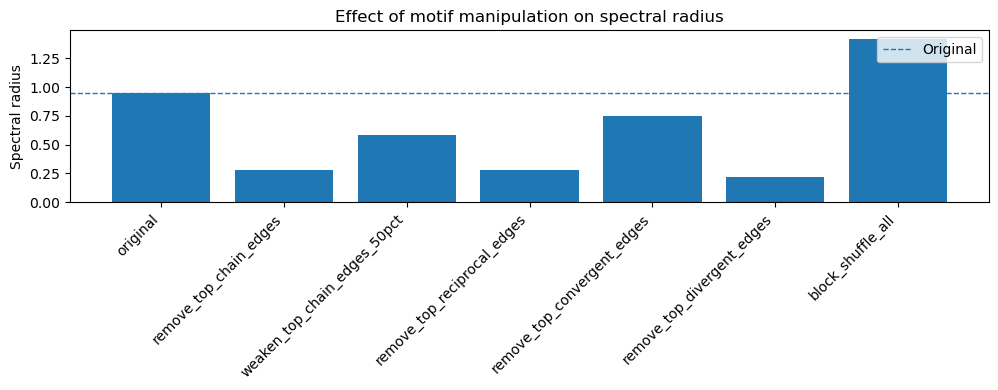

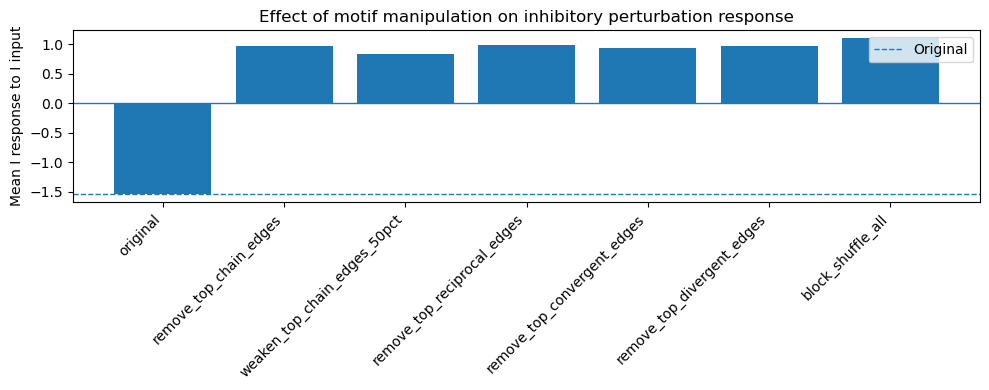

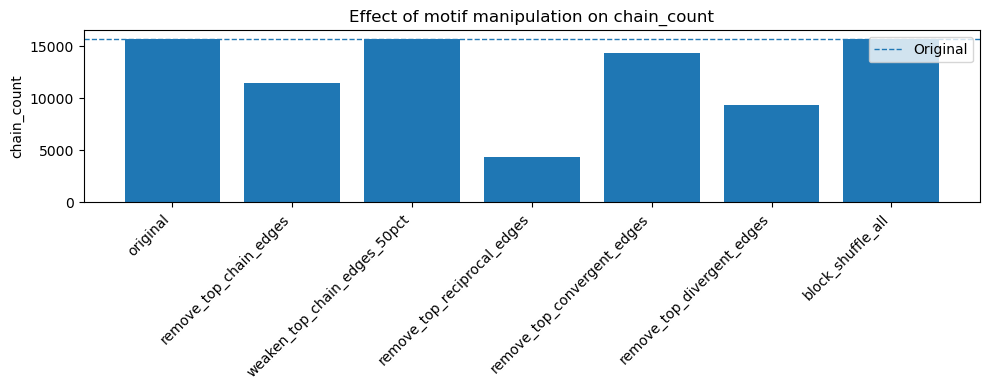

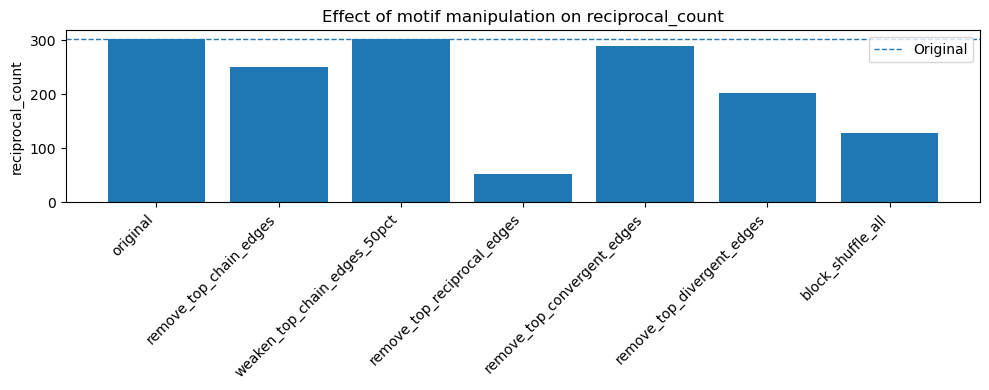

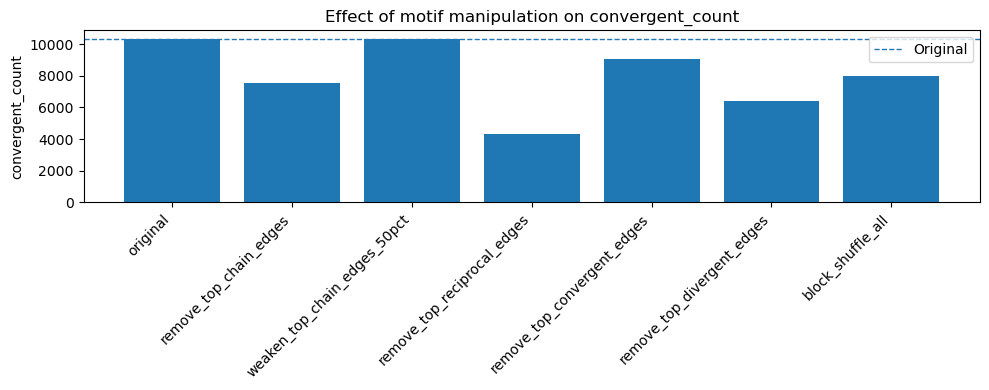

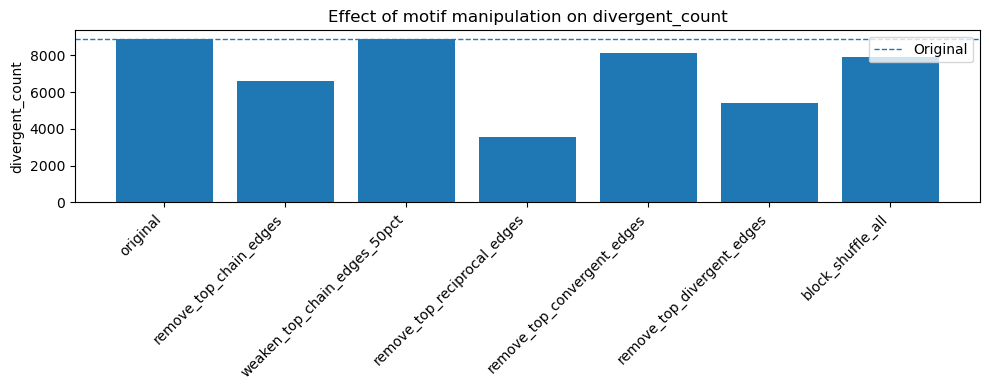

In [37]:
# Section 8.1 Plot motif experiment effects

plot_df = motif_experiment_summary.copy()

plt.figure(figsize=(10, 4))
plt.bar(plot_df["condition"], plot_df["spectral_radius"])
plt.axhline(
    baseline["spectral_radius"],
    linestyle="--",
    linewidth=1,
    label="Original"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Spectral radius")
plt.title("Effect of motif manipulation on spectral radius")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
plt.bar(plot_df["condition"], plot_df["mean_I_to_I_input"])
plt.axhline(0, linewidth=1)
plt.axhline(
    baseline["mean_I_to_I_input"],
    linestyle="--",
    linewidth=1,
    label="Original"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean I response to I input")
plt.title("Effect of motif manipulation on inhibitory perturbation response")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


count_cols = ["chain_count", "reciprocal_count", "convergent_count", "divergent_count"]

for col in count_cols:
    plt.figure(figsize=(10, 4))
    plt.bar(plot_df["condition"], plot_df[col])
    plt.axhline(
        baseline[col],
        linestyle="--",
        linewidth=1,
        label="Original"
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(col)
    plt.title(f"Effect of motif manipulation on {col}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [38]:
# Section 8.2 Auto-interpret motif experiment results

def interpret_motif_experiment(summary_df):
    base = summary_df.loc[summary_df["condition"].eq("original")].iloc[0]
    lines = []

    lines.append("## Section 8 Interpretation: Motif Removal / Scrambling Experiment\n")

    lines.append(
        f"The original normalized matrix has spectral radius "
        f"{base['spectral_radius']:.4f} and dominant eigenvalue "
        f"{base['dominant_eigenvalue_real']:.4f} + "
        f"{base['dominant_eigenvalue_imag']:.4f}i."
    )

    # Spectral radius effects
    spectral_changes = summary_df[summary_df["condition"] != "original"].copy()
    spectral_changes["abs_delta_spectral_radius"] = spectral_changes["delta_spectral_radius"].abs()

    strongest_spectral = spectral_changes.sort_values(
        "abs_delta_spectral_radius", ascending=False
    ).iloc[0]

    lines.append(
        f"\nThe manipulation with the largest effect on spectral radius was "
        f"`{strongest_spectral['condition']}`, changing spectral radius by "
        f"{strongest_spectral['delta_spectral_radius']:.4f}."
    )

    if strongest_spectral["delta_spectral_radius"] < -0.05:
        lines.append(
            "This suggests that the removed or scrambled structure contributes to the dominant recurrent mode."
        )
    elif strongest_spectral["delta_spectral_radius"] > 0.05:
        lines.append(
            "This suggests that the manipulation increased recurrence, possibly by removing suppressive or balancing structure."
        )
    else:
        lines.append(
            "The spectral radius changed only modestly, suggesting the dominant mode is robust to this manipulation."
        )

    # Chain-specific interpretation
    if "remove_top_chain_edges" in summary_df["condition"].values:
        chain_row = summary_df.loc[
            summary_df["condition"].eq("remove_top_chain_edges")
        ].iloc[0]

        lines.append(
            f"\nRemoving top chain-associated edges changed spectral radius by "
            f"{chain_row['delta_spectral_radius']:.4f} and changed chain count by "
            f"{chain_row['delta_chain_count']:.0f}."
        )

        if chain_row["delta_spectral_radius"] < -0.05:
            lines.append(
                "This supports the Shao-style interpretation that chain-related structure helps generate the leading positive mode."
            )
        else:
            lines.append(
                "This does not strongly support chain motifs as the sole driver of the leading mode; block structure, reciprocal loops, or distributed pathways may also be important."
            )

    # Reciprocal interpretation
    if "remove_top_reciprocal_edges" in summary_df["condition"].values:
        rec_row = summary_df.loc[
            summary_df["condition"].eq("remove_top_reciprocal_edges")
        ].iloc[0]

        lines.append(
            f"\nRemoving top reciprocal-associated edges changed spectral radius by "
            f"{rec_row['delta_spectral_radius']:.4f}."
        )

        if abs(rec_row["delta_spectral_radius"]) > 0.05:
            lines.append(
                "Reciprocal motifs appear to contribute meaningfully to recurrent feedback."
            )
        else:
            lines.append(
                "Reciprocal motifs do not appear to dominate the leading recurrent mode under this manipulation."
            )

    # Paradoxical response interpretation
    base_I_response = base["mean_I_to_I_input"]

    lines.append(
        f"\nIn the original matrix, mean inhibitory response to broad inhibitory input was "
        f"{base_I_response:.4f}."
    )

    if base_I_response < 0:
        lines.append(
            "This is a paradoxical inhibitory response: increasing input to inhibitory nodes decreases their steady-state activity."
        )
    else:
        lines.append(
            "This is not paradoxical under the current normalization and perturbation setup."
        )

    changed_paradox = summary_df[
        summary_df["paradoxical_I_response"] != base["paradoxical_I_response"]
    ]

    if len(changed_paradox) > 0:
        conditions = ", ".join(changed_paradox["condition"].tolist())
        lines.append(
            f"\nThe paradoxical-response classification changed under: {conditions}."
        )
        lines.append(
            "That means motif structure may affect perturbation-response regime, not just raw connectivity statistics."
        )
    else:
        lines.append(
            "\nThe paradoxical-response classification did not change across these manipulations."
        )
        lines.append(
            "That suggests the response regime is robust, or that stronger/more targeted motif perturbations are needed."
        )

    # Overall conclusion
    lines.append(
        "\nOverall, interpret this experiment as a causal stress test: if removing a motif class reduces the dominant eigenvalue or flips response signs, that motif class is dynamically important. If not, the network's behavior is probably distributed across multiple structures rather than controlled by one motif type. Naturally, biology chose the less convenient option until proven otherwise."
    )

    return "\n".join(lines)


section8_interpretation = interpret_motif_experiment(motif_experiment_summary)

print(section8_interpretation)

with open(OUTPUT_DIR / "section8_auto_interpretation.md", "w", encoding="utf-8") as f:
    f.write(section8_interpretation)

## Section 8 Interpretation: Motif Removal / Scrambling Experiment

The original normalized matrix has spectral radius 0.9500 and dominant eigenvalue 0.9500 + 0.0000i.

The manipulation with the largest effect on spectral radius was `remove_top_divergent_edges`, changing spectral radius by -0.7306.
This suggests that the removed or scrambled structure contributes to the dominant recurrent mode.

Removing top chain-associated edges changed spectral radius by -0.6668 and changed chain count by -4274.
This supports the Shao-style interpretation that chain-related structure helps generate the leading positive mode.

Removing top reciprocal-associated edges changed spectral radius by -0.6721.
Reciprocal motifs appear to contribute meaningfully to recurrent feedback.

In the original matrix, mean inhibitory response to broad inhibitory input was -1.5493.
This is a paradoxical inhibitory response: increasing input to inhibitory nodes decreases their steady-state activity.

The paradoxical-res

In [39]:
# Section 8.3 Save outputs

motif_experiment_summary.to_csv(
    OUTPUT_DIR / "section8_motif_experiment_summary.csv",
    index=False
)

for condition, A_cond in A_conditions.items():
    pd.DataFrame(A_cond, index=nodes, columns=nodes).to_csv(
        OUTPUT_DIR / f"section8_matrix_{condition}.csv"
    )

print(f"Saved Section 8 outputs to: {OUTPUT_DIR}")

Saved Section 8 outputs to: /Users/raniceto/Library/CloudStorage/OneDrive-GeorgeMasonUniversity-O365Production/04_2026 Spring/BINF751 - Biochem Modeling/Final Project/outputs


# Bonus Analysis: Likely Dominant Flow Routes
## Greedy strongest-path tracing

Idea:
-  Start from a node (e.g., high eigenvector loading node)
-  At each step, follow the strongest outgoing edge
-  Stop when you revisit a node

**What it tells you**
-  Strongest local routes
-  Likely feedforward chains
-  Rough hippocampal flow structure

**What it does NOT tell you**
-  true dynamics
-  parallel contributions
-  inhibitory modulation

In [40]:
# Greedy strongest-path tracing

def greedy_path(J, start_node, max_steps=10):
    path = [start_node]
    visited = set(path)

    current = start_node

    for _ in range(max_steps):
        outgoing = J.loc[:, current].copy()  # source = current
        outgoing = outgoing.drop(labels=current, errors="ignore")

        # remove visited nodes
        outgoing = outgoing.drop(labels=[n for n in outgoing.index if n in visited], errors="ignore")

        if outgoing.empty:
            break

        next_node = outgoing.abs().idxmax()

        path.append(next_node)
        visited.add(next_node)
        current = next_node

    return path


# Example: start from top dominant-mode nodes
paths = []
for node in df_dom.head(5)["node"]:
    paths.append((node, greedy_path(J, node)))

for start, p in paths:
    print(f"{start}: {' -> '.join(p)}")

EC LI II Multipolar Pyramidal: EC LI II Multipolar Pyramidal -> EC LI II Pyramidal Fan -> EC LII III Pyramidal Tripolar -> MEC LII Stellate -> MEC LIII Complex Pyramidal -> MEC LV Pyramidal -> CA1 Pyramidal -> CA3c Pyramidal -> CA3 Pyramidal -> DG Granule -> DG Basket
CA3 Pyramidal: CA3 Pyramidal -> MEC LII Stellate -> EC LI II Multipolar Pyramidal -> EC LI II Pyramidal Fan -> EC LII III Pyramidal Tripolar -> LEC LIII Complex Pyramidal -> EC LIV VI Deep Multipolar Principal -> CA1 Pyramidal -> CA3c Pyramidal -> DG Granule -> MEC LV Pyramidal
CA3c Pyramidal: CA3c Pyramidal -> CA3 Pyramidal -> MEC LII Stellate -> EC LI II Multipolar Pyramidal -> EC LI II Pyramidal Fan -> EC LII III Pyramidal Tripolar -> LEC LIII Complex Pyramidal -> EC LIV VI Deep Multipolar Principal -> CA1 Pyramidal -> EC LIII Pyramidal -> EC LIII V Bipolar Pyramidal
EC LI II Pyramidal Fan: EC LI II Pyramidal Fan -> EC LI II Multipolar Pyramidal -> EC LII III Pyramidal Tripolar -> MEC LII Stellate -> MEC LIII Complex P

## Eigenmode-weighted pathways (this is the Shao-consistent version)
Weight edges by how strongly both nodes participate in a mode:

edge score = $|v_i \cdot J_{ji} \cdot v_j|$

This finds edges that actually contribute to the dominant mode and answers:

*“Which edges actually carry the dominant eigenmode?”*

In [41]:
# Eigenmode-weighted edge importance

v = df_dom.set_index("node")["loading_real"]

edge_scores = []

for source in J.columns:
    for target in J.index:
        w = J.loc[target, source]
        if w != 0:
            score = abs(v[source] * w * v[target])
            edge_scores.append({
                "source": source,
                "target": target,
                "weight": w,
                "score": score
            })

df_edges = pd.DataFrame(edge_scores)
df_edges = df_edges.sort_values("score", ascending=False)

display(df_edges.head(20))

,source,target,weight,score
861,EC LII III Pyramidal Tripolar,EC LI II Multipolar Pyramidal,1.183113,0.155071
226,CA3c Pyramidal,CA3 Pyramidal,0.945404,0.136393
350,CA1 Pyramidal,CA3c Pyramidal,7.040999,0.124145
852,MEC LII Stellate,EC LI II Multipolar Pyramidal,0.577264,0.120022
222,CA3 Pyramidal,MEC LII Stellate,0.652198,0.078830
806,EC LI II Multipolar Pyramidal,EC LI II Pyramidal Fan,0.327465,0.073406
817,EC LI II Pyramidal Fan,EC LI II Multipolar Pyramidal,0.324674,0.072780
809,EC LI II Multipolar Pyramidal,EC LII III Pyramidal Tripolar,0.184775,0.024219
889,EC LIII Pyramidal,EC LI II Multipolar Pyramidal,1.190922,0.023802
349,CA1 Pyramidal,CA3 Pyramidal,0.909886,0.016496


In [42]:
# Build top pathways from strongest edges

top_edges = df_edges.head(50)

print("Top candidate edges:")
for _, row in top_edges.head(15).iterrows():
    print(f"{row['source']} -> {row['target']} (score={row['score']:.4f})")

Top candidate edges:
EC LII III Pyramidal Tripolar -> EC LI II Multipolar Pyramidal (score=0.1551)
CA3c Pyramidal -> CA3 Pyramidal (score=0.1364)
CA1 Pyramidal -> CA3c Pyramidal (score=0.1241)
MEC LII Stellate -> EC LI II Multipolar Pyramidal (score=0.1200)
CA3 Pyramidal -> MEC LII Stellate (score=0.0788)
EC LI II Multipolar Pyramidal -> EC LI II Pyramidal Fan (score=0.0734)
EC LI II Pyramidal Fan -> EC LI II Multipolar Pyramidal (score=0.0728)
EC LI II Multipolar Pyramidal -> EC LII III Pyramidal Tripolar (score=0.0242)
EC LIII Pyramidal -> EC LI II Multipolar Pyramidal (score=0.0238)
CA1 Pyramidal -> CA3 Pyramidal (score=0.0165)
DG Granule -> CA3c Pyramidal (score=0.0140)
CA2 Wide Arbor Basket -> CA3c Pyramidal (score=0.0127)
MEC LII Stellate -> EC LI II Pyramidal Fan (score=0.0124)
DG Granule -> EC LI II Pyramidal Fan (score=0.0112)
EC LI II Multipolar Pyramidal -> MEC LII Stellate (score=0.0108)


## Response-based pathways (most honest biologically)
Idea:
-  Stimulate a node or region
-  Track which nodes respond most strongly
-  Follow response propagation

This answers:

*“If I stimulate here, where does activity actually go?”*

In [43]:
# Trace response propagation

def response_path(response_df, top_n=10):
    return (
        response_df
        .sort_values("abs_response", ascending=False)
        .head(top_n)[["node", "response"]]
    )

# Example
resp = node_response_tables["input_all_E"]
display(response_path(resp, top_n=15))

,node,response
51,EC LI II Multipolar Pyramidal,416.939565
14,CA3c Pyramidal,281.058642
13,CA3 Pyramidal,278.234982
55,MEC LII Stellate,213.602250
52,EC LI II Pyramidal Fan,211.737510
56,EC LII III Pyramidal Tripolar,123.803829
0,DG Granule,74.757525
67,MEC LV Pyramidal,44.273613
27,CA1 Pyramidal,36.197564
58,EC LIII Pyramidal,22.873572


## Exploring Eigenmodes...

In [44]:
# ============================================================
# Expanded Eigenmode Ownership: All 72 Eigenvalues
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = J.to_numpy(dtype=float)
nodes = list(J.index)
n = A.shape[0]

eigvals, eigvecs = np.linalg.eig(A)
order = np.argsort(np.abs(eigvals))[::-1]

records = []

for rank, eig_idx in enumerate(order, start=1):
    lam = eigvals[eig_idx]
    v = eigvecs[:, eig_idx]

    # Normalize so loadings are comparable across modes
    v = v / np.linalg.norm(v)

    for node, loading in zip(nodes, v):
        records.append({
            "mode_rank": rank,
            "eig_index": eig_idx,
            "node": node,
            "lambda_real": lam.real,
            "lambda_imag": lam.imag,
            "lambda_abs": np.abs(lam),
            "loading_real": loading.real,
            "loading_imag": loading.imag,
            "loading_abs": np.abs(loading),
            "loading_power": np.abs(loading)**2
        })

df_all_modes = pd.DataFrame(records)

# Add metadata if available
if "node_types" in globals():
    df_all_modes["node_type"] = df_all_modes["node"].map(node_types["node_type"])

if "region" in node_types.columns:
    df_all_modes["region"] = df_all_modes["node"].map(node_types["region"])

display(df_all_modes.head())

df_all_modes.to_csv(OUTPUT_DIR / "all_72_eigenmode_ownership.csv", index=False)

,mode_rank,eig_index,node,lambda_real,lambda_imag,lambda_abs,loading_real,loading_imag,loading_abs,loading_power,node_type
0,1,0,DG Granule,0.95,0.0,0.95,-0.097427,0.0,0.097427,9.491999e-03,E
1,1,0,DG Semilunar Granule,0.95,0.0,0.95,-0.016825,0.0,0.016825,2.830938e-04,E
2,1,0,DG Mossy,0.95,0.0,0.95,-0.004434,0.0,0.004434,1.966132e-05,E
3,1,0,DG AIPRIM,0.95,0.0,0.95,0.001311,0.0,0.001311,1.717500e-06,I
4,1,0,DG Axo Axonic,0.95,0.0,0.95,0.000027,0.0,0.000027,7.558231e-10,I


In [45]:
top_k = 10

df_top_mode_owners = (
    df_all_modes
    .sort_values(["mode_rank", "loading_abs"], ascending=[True, False])
    .groupby("mode_rank")
    .head(top_k)
    .reset_index(drop=True)
)

display(df_top_mode_owners)

df_top_mode_owners.to_csv(
    OUTPUT_DIR / "top_owners_by_eigenmode.csv",
    index=False
)

,mode_rank,eig_index,node,lambda_real,lambda_imag,lambda_abs,loading_real,loading_imag,loading_abs,loading_power,node_type
0,1,0,EC LI II Multipolar Pyramidal,0.950000,0.0,0.950000,-0.662545,0.0,0.662545,0.438966,E
1,1,0,CA3 Pyramidal,0.950000,0.0,0.950000,-0.385160,0.0,0.385160,0.148348,E
2,1,0,CA3c Pyramidal,0.950000,0.0,0.950000,-0.374570,0.0,0.374570,0.140303,E
3,1,0,EC LI II Pyramidal Fan,0.950000,0.0,0.950000,-0.338338,0.0,0.338338,0.114472,E
4,1,0,MEC LII Stellate,0.950000,0.0,0.950000,-0.313813,0.0,0.313813,0.098479,E
...,...,...,...,...,...,...,...,...,...,...,...
715,72,67,MEC LIII Bipolar Complex Pyramidal,0.000017,0.0,0.000017,-0.184086,0.0,0.184086,0.033887,E
716,72,67,MEC LIII Superficial Trilayered Interneuron,0.000017,0.0,0.000017,-0.175178,0.0,0.175178,0.030687,I
717,72,67,MEC LV VI Pyramidal Polymorphic,0.000017,0.0,0.000017,-0.172404,0.0,0.172404,0.029723,E
718,72,67,CA1 O LMR,0.000017,0.0,0.000017,-0.137238,0.0,0.137238,0.018834,I


In [46]:
df_recurrent_owners = (
    df_top_mode_owners
    .groupby("node")
    .agg(
        n_modes_owned=("mode_rank", "nunique"),
        mean_loading_abs=("loading_abs", "mean"),
        max_loading_abs=("loading_abs", "max"),
        strongest_mode=("mode_rank", "min")
    )
    .sort_values(["n_modes_owned", "mean_loading_abs"], ascending=False)
    .reset_index()
)

display(df_recurrent_owners.head(20))

,node,n_modes_owned,mean_loading_abs,max_loading_abs,strongest_mode
0,EC LI II Pyramidal Fan,71,0.501369,0.955395,1
1,MEC LII Stellate,63,0.356078,0.811918,1
2,EC LII III Pyramidal Tripolar,63,0.207724,0.342810,1
3,MEC LII III Pyramidal Multiform,60,0.264495,0.458858,9
4,EC LIII Pyramidal,55,0.300215,0.517303,11
5,MEC LIII Bipolar Complex Pyramidal,45,0.245891,0.868600,15
6,MEC LII Oblique Pyramidal,41,0.310927,0.665513,21
7,MEC LIII Superficial Trilayered Interneuron,36,0.170100,0.407998,26
8,MEC LIII Complex Pyramidal,34,0.192135,0.562112,1
9,EC LIII Stellate,33,0.193381,0.691451,33


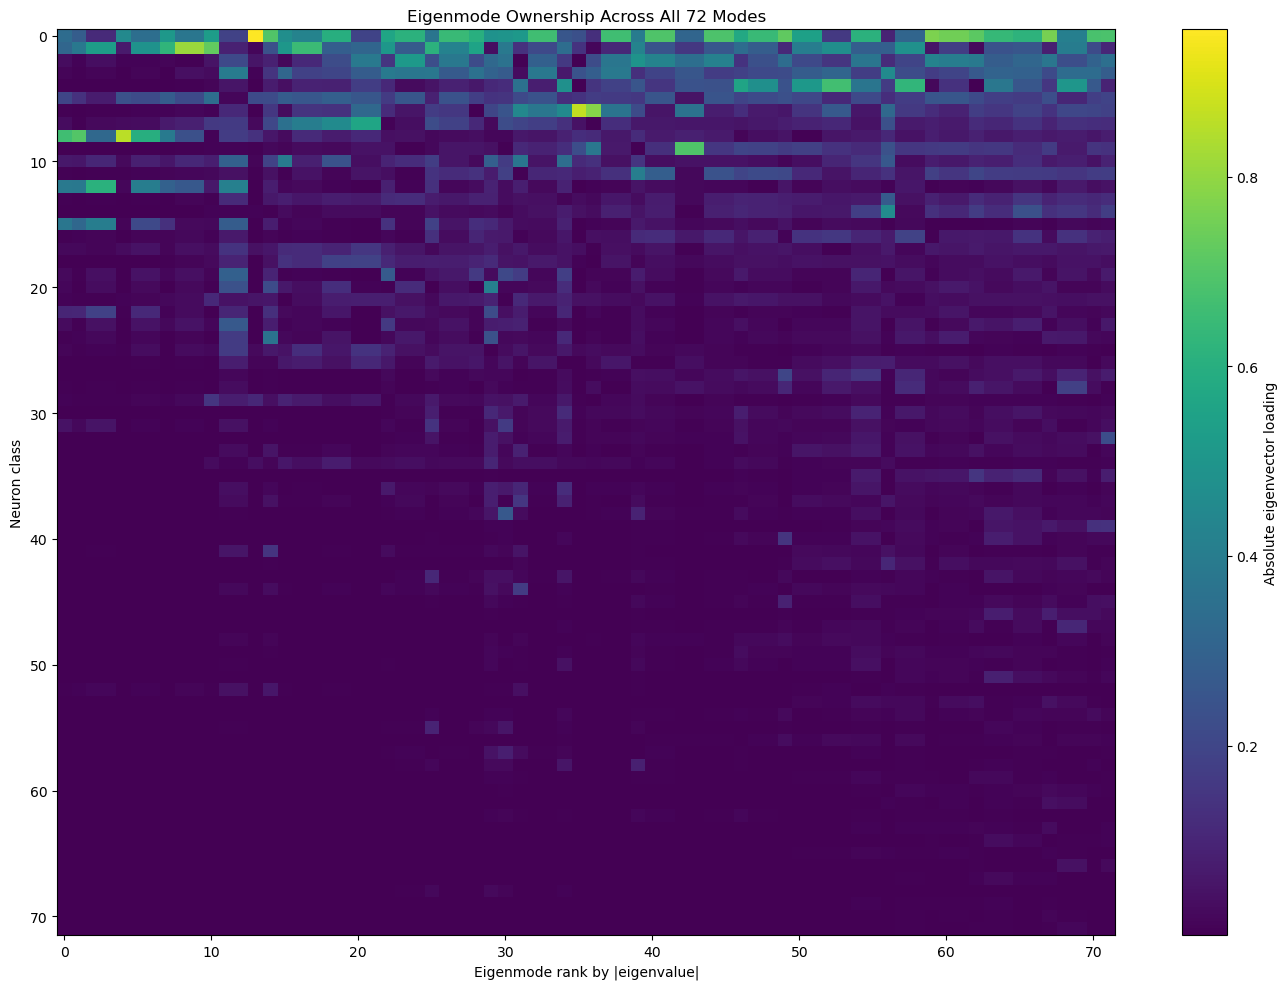

In [47]:
ownership_matrix = (
    df_all_modes
    .pivot_table(index="node", columns="mode_rank", values="loading_abs")
)

# Optional: order nodes by strongest total participation
node_order = ownership_matrix.sum(axis=1).sort_values(ascending=False).index
ownership_matrix = ownership_matrix.loc[node_order]

plt.figure(figsize=(14, 10))
plt.imshow(ownership_matrix, aspect="auto")
plt.colorbar(label="Absolute eigenvector loading")
plt.xlabel("Eigenmode rank by |eigenvalue|")
plt.ylabel("Neuron class")
plt.title("Eigenmode Ownership Across All 72 Modes")
plt.tight_layout()
plt.show()